# Hybrid Book Recommender System 
### Dual-Embedding NLP · Negation-Aware Intent · Composite Collaborative Score

**Architecture:**
```
User Query
  └─► Phase 1 — NLP Intent
        normalize_query()          synonym expansion (lgbt→lgbtq, sad→emotional…)
        extract_intent_final()
          ├─ Negation detection    _get_negated_indices() → negative_keywords
          ├─ Unrequited-love probe love + negation → inject 'unrequited love' trope
          ├─ Layer 1: keyword dict matching  (TROPE_KEYWORDS, TONE_KEYWORDS)
          └─ Layer 2: zero-shot semantic     (SentenceTransformer cos-sim)
        build_query_text()         weighted "vibe" string

  └─► Phase 2 — Scoring
        Content Score  (weight 0.6)
          process_query()          clean → encode → L2-normalize → (1,384)
          compute_similarity()     0.7 × desc_emb + 0.3 × review_emb
          Genre/Trope boost        +0.05 on matching books

        Collab Score   (weight 0.4)  — composite
          collab = 0.5 × bayesian_score      ← rating + totalratings from 6000_books.csv
                 + 0.3 × interaction_score   ← save, click, search, purchase, share
                 + 0.2 × sentiment_score     ← polarity, objectivity

  └─► Phase 3 — Final Blend
        final_score = 0.6 × content_score + 0.4 × collab_score
        negative_keywords penalise matching books (−0.10 each)
        → filter already-read → sort → top-N
```
**Input files:** `6000_bookssamples.csv` · `review_clean.csv` · `interaction.csv`


The scoring pipeline uses predefined weights to combine two main signal sources into a unified recommendation score. Specifically, the system prioritizes **content (w = 0.6)** to ensure relevance to the query through semantic similarity computation. Within this, when comparing user intent with book content, **description embedding (w = 0.7)** is given more weight than **review embedding (w = 0.3)** to better capture the core content.

Additionally, a **trope/genre boost (+0.05)** is applied to enhance alignment with user intent, especially for narrative-driven queries.

In parallel, the **collaborative component (w = 0.4)** aggregates signals from **Bayesian score**, **interaction score**, and **sentiment score**, reflecting overall quality, popularity, and user perception of each book. These two components are linearly combined to produce the **final score**, along with a **negative penalty** mechanism to handle negation constraints in queries, before filtering and ranking results.

This weight allocation clearly reflects a **content-driven** approach, prioritizing accurate understanding of user intent while still leveraging community signals to ensure stability, reliability, and practical effectiveness of the recommendation system.


**Install dependencies (run once)**

In [1]:
# Uncomment and run once, then comment out again
!pip install scikit-learn pandas numpy matplotlib seaborn
!pip install spacy && python -m spacy download en_core_web_sm
!pip install sentence-transformers


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 220.2 kB/s eta 0:00:59
     --------------------------------------- 0.0/12.8 MB 196.9 kB/s eta 0:01:05
     --------------------------------------- 0.1/12.8 MB 252.2 kB/s eta 0:00:51
     --------------------------------------- 0.1/12.8 MB 350.1 kB/s eta 0:00:37
     --------------------------------------- 0.1/12.8 MB 473.7 kB/s eta 0:00:27
      -------------------------------------- 0.3/12.8 MB 749.3 kB/s eta 0:00:17
     - -------------------------------------- 0.5/12.8 MB 1.3 MB/s eta 0:00:10
     -- ------------------------------------- 0.7/12.8 MB 1.5 MB/s eta 0:00:09
     --- ------------------------------------ 1.1/12.8 MB 2.2 MB/s eta 0:0

## 1/ Imports & global settings

In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler, normalize as sk_normalize

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# ── SentenceTransformer ───────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer, util as st_util
print("Loading SentenceTransformer (all-MiniLM-L6-v2)...")
model = SentenceTransformer("all-MiniLM-L6-v2")
print("[✓] Model loaded")

# ── spaCy ─────────────────────────────────────────────────────────────────
import spacy
nlp = spacy.load("en_core_web_sm")
print("[✓] spaCy en_core_web_sm loaded")


Loading SentenceTransformer (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[✓] Model loaded
[✓] spaCy en_core_web_sm loaded


## 2/ NLP Constants
Keyword dictionaries, negation helpers, synonym normaliser, and TROPE_LABELS (curated + data-mined, deduped).


In [3]:
# ── Trope keyword triggers ────────────────────────────────────────────────
TROPE_KEYWORDS = {
    "survival":           ["survival", "survive", "wilderness", "stranded", "rescue", "endurance"],
    "romance":            ["love", "romance", "relationship", "heartbreak", "passion"],
    "redemption":         ["redemption", "forgiveness", "second chance", "overcome",
                           "overcoming", "obstacles", "finding yourself", "self discovery", "growth"],
    "mystery":            ["mystery", "detective", "clue", "investigation", "thriller"],
    "coming_of_age":      ["coming of age", "growing up", "youth", "self-discovery",
                           "finding yourself", "who you are", "identity"],
    "conspiracy":         ["conspiracy", "cover up", "secret", "hidden truth"],
    "adventure":          ["adventure", "quest", "journey", "expedition"],
    "war":                ["war", "battle", "soldier", "combat", "military"],
    "friendship":         ["friendship", "loyalty", "bond", "companion"],
    "historical_fiction": ["historical fiction", "historical", "history",
                           "period drama", "set in the past", "historical novel"],
    "heist":              ["heist", "robbery", "steal", "caper"],
    "dystopia":           ["dystopia", "dystopian", "post-apocalyptic", "totalitarian"],
    "magic":              ["magic", "wizard", "spell", "sorcery", "enchant"],
    "revenge":            ["revenge", "vengeance", "payback", "retaliation"],
    "time_travel":        ["time travel", "time machine", "paradox"],
    "unrequited_love":    ["unrequited", "not returned", "one sided", "one-sided", "unrequited love"],
}

# ── Tone keyword triggers ─────────────────────────────────────────────────
TONE_KEYWORDS = {
    "emotional":   ["emotional", "moving", "touching", "heartfelt", "deep", "poignant"],
    "funny":       ["funny", "humor", "comedy", "witty", "lighthearted", "light-hearted"],
    "dark":        ["dark", "grim", "bleak", "disturbing", "haunting"],
    "inspiring":   ["inspiring", "uplifting", "motivational", "hopeful", "inspired"],
    "educational": ["informative", "educational", "insightful", "detailed"],
    "tense":       ["tense", "suspense", "gripping", "thrilling", "intense"],
    "cozy":        ["cozy", "warm", "comfort", "wholesome", "gentle"],
    "romantic":    ["romantic", "swoon", "butterflies", "sweet"],
    "atmospheric": ["atmospheric", "ambiance", "mood", "immersive", "vivid"],
}

# ── Genre fallback classifier ─────────────────────────────────────────────
GENRE_KEYWORDS = {
    "fantasy":            ["magic", "dragon", "wizard", "spell", "quest", "realm", "enchant", "prophecy"],
    "science fiction":    ["space", "robot", "alien", "future", "dystopia", "technology", "cyberpunk"],
    "mystery":            ["detective", "murder", "crime", "clue", "suspect", "investigation", "thriller"],
    "romance":            ["love", "romance", "relationship", "passion", "heart", "kiss", "attraction"],
    "horror":             ["horror", "scary", "ghost", "haunted", "terror", "supernatural", "demon"],
    "historical fiction": ["historical", "history", "war", "century", "ancient", "empire", "medieval"],
    "self-help":          ["self help", "mindset", "habit", "success", "productivity", "motivation"],
    "biography":          ["biography", "memoir", "autobiography", "true story", "personal"],
    "science":            ["science", "research", "experiment", "theory", "evolution", "biology", "physics"],
    "adventure":          ["adventure", "journey", "expedition", "survival", "explore", "wilderness"],
    "young adult":        ["ya", "teen", "young adult", "high school"],
    "thriller":           ["thriller", "suspense", "espionage", "conspiracy", "chase"],
    "nonfiction":         ["nonfiction", "non-fiction", "true", "real", "factual"],
}

GENRE_ALIAS = {
    "self help": "self-help", "selfhelp": "self-help",
    "sci fi": "science fiction", "scifi": "science fiction", "sf": "science fiction",
    "ya": "young adult", "non fiction": "nonfiction", "non-fiction": "nonfiction",
    "hist fiction": "historical fiction", "historical": "historical fiction",
    "literary fiction": "literary", "lgbtq": "lgbtq", "lgbt": "lgbtq",
    "childrens": "children's", "picture books": "children's",
    "paranormal": "paranormal romance",
}

GENRE_BLACKLIST = {
    "favorites", "owned", "kindle", "to-read", "default",
    "audiobook", "ebook", "library", "read", "books",
    "my books", "to read", "currently reading", "wish list",
    "series", "recommended", "adult", "fiction",
}

# ── Negation helpers (appp.py v4.0++ compatible) ──────────────────────────
NEGATION_CUES = {"not", "no", "without", "never", "don't", "doesnt",
                 "isn't", "aren't", "wasn't", "weren't", "hardly", "barely", "lack", "lacking", "n't"}

def _get_negated_indices_simple(query: str) -> set:
    """Enhanced negation detection with semantic breaks.
    
    Captures ALL content words after negation cue until hitting semantic connector
    (but, and, or, however, though, yet, still, although).
    
    Examples:
    - "not a romance" → negates "romance"
    - "not romance and fantasy" → negates "romance" (stops at "and")
    - "but definitely not a romance." → negates "romance"
    """
    negated = set()
    # Remove punctuation for cleaner word splitting
    query_clean = re.sub(r'[.,!?;:]', '', query.lower())
    words = query_clean.split()
    
    # Semantic breaks that stop negation scope
    semantic_breaks = {"but", "and", "or", "however", "though", "yet",
                       "still", "although", "whereas", "until", "unless"}

    for i, w in enumerate(words):
        if w in NEGATION_CUES:
            # Collect ALL words after negation until semantic break or end
            for j in range(i + 1, len(words)):
                # Stop at semantic break
                if words[j] in semantic_breaks:
                    break
                # Mark non-trivial words as negated
                if len(words[j]) > 2 and words[j] not in NEGATION_CUES:
                    negated.add(j)

    return negated

def _get_negated_indices(doc) -> set:
    """spaCy dependency-tree negation (kept for backward compat).
    Uses enhanced simple version for reliable negation scope."""
    # Build a plain string from doc tokens for the enhanced detector
    query_str = " ".join(t.text for t in doc)
    return _get_negated_indices_simple(query_str)


def remove_negated_base_tropes(query: str, tropes: list) -> list:
    """
    Post-processor for negation handling (from appp.py).
    Extracts negated words from query and removes any tropes that match.
    Uses bidirectional substring matching and smart word extraction.

    Example: query="not romance" → removes any trope containing "romance"
    """
    query_lower = query.lower()

    skip_words = {"a", "an", "the", "any", "some", "all", "this", "that", "these", "those"}

    negated_words = set()

    patterns = [
        r'not\s+(?:a\s+|an\s+|the\s+)?([\w]+)',
        r'no\s+(?:a\s+|an\s+|the\s+)?([\w]+)',
        r'without\s+(?:a\s+|an\s+|the\s+)?(?:any\s+)?([\w]+)',
        r'definitely\s+not\s+(?:a\s+|an\s+|the\s+)?([\w]+)',
        r'never\s+(?:a\s+|an\s+|the\s+)?([\w]+)',
    ]

    for pattern in patterns:
        matches = re.findall(pattern, query_lower)
        negated_words.update(m for m in matches if m not in skip_words)

    if not negated_words:
        return tropes

    filtered_tropes = []
    for trope in tropes:
        trope_lower = trope.lower()
        trope_underscored = trope_lower.replace(" ", "_")

        is_negated = any(
            (neg_word in trope_lower or trope_lower in neg_word or
             neg_word in trope_underscored or trope_underscored in neg_word)
            for neg_word in negated_words
        )

        if not is_negated:
            filtered_tropes.append(trope)

    return filtered_tropes

# ── Synonym / query normaliser ────────────────────────────────────────────
QUERY_NORMALIZER = {
    "lgbt":       "lgbtq",
    "queer":      "lgbtq",
    "gay":        "lgbtq",
    "lesbian":    "lgbtq",
    "sapphic":    "lgbtq",
    "wlw":        "lgbtq",
    "mlm":        "lgbtq",
    "sad":        "emotional",
    "cry":        "emotional",
    "tearjerker": "emotional",
    "rom com":    "funny romance",
    "romcom":     "funny romance",
    "sci fi":     "science fiction",
    "scifi":      "science fiction",
}

def normalize_query(query: str) -> str:
    """Word-boundary synonym expansion before keyword matching."""
    q = str(query).lower()
    for variant, canonical in QUERY_NORMALIZER.items():
        q = re.sub(r"\b" + re.escape(variant) + r"\b", canonical, q)
    return q

# ── TROPE_LABELS — curated + data-mined, deduped ─────────────────────────
TROPE_LABELS_CURATED = [
    "enemies to lovers", "forbidden love", "second chance romance",
    "love triangle", "slow burn romance", "fake dating",
    "marriage of convenience", "unrequited love", "soulmates", "friends to lovers",
    "redemption arc", "coming of age", "chosen one", "antihero",
    "villain protagonist", "reluctant hero", "found family",
    "mentor and student", "underdog story", "identity crisis",
    "revenge plot", "heist", "mystery", "conspiracy", "survival",
    "quest", "adventure", "time travel", "prophecy", "tournament",
    "road trip", "fish out of water", "mistaken identity",
    "secret identity", "betrayal", "unreliable narrator", "twist ending", "whodunit",
    "dystopia", "post-apocalyptic", "magic system", "political intrigue",
    "war", "historical setting", "small town", "school or academy",
    "royalty and nobility", "space exploration", "parallel worlds", "cozy setting",
    "grief and loss", "trauma and healing", "mental health",
    "loneliness and isolation", "hope and resilience",
    "dark and gritty", "lighthearted and cozy", "bittersweet",
    "philosophical themes", "class struggle", "coming out story",
    "immigrant experience", "female friendship and sisterhood",
    "multiple POV", "epistolary format", "nonlinear timeline", "dual timeline",
    "vampire", "werewolf", "fae and fairy tale", "demons and angels",
    "detective noir", "cozy mystery", "legal thriller",
    "medical drama", "sports story", "superhero", "friendship",
]

TROPE_LABELS_MINED = [
    "anthology and short stories", "design and architecture", "superhero comics",
    "family drama", "historical romance", "epic fantasy", "fairy tale retelling",
    "poetry collection", "sports story", "asian history and culture",
    "cookbook and food", "relationships and sexuality", "self-help guide", "manga",
    "christian and religious fiction", "personal development",
    "world war military history", "american political history",
    "nature and wildlife", "graphic novel and comics", "crafts and hobbies",
    "science and nature for kids", "civil war history", "jewish history and culture",
    "holiday and seasonal", "biblical commentary", "children's picture book",
    "quilting and sewing", "film and cinema", "animals and nature",
    "russian and soviet history", "pets and animal care", "mathematics and textbook",
    "murder mystery detective", "contemporary romance", "art and visual culture",
    "literary fiction", "health diet and nutrition", "business and management",
    "pirates and nautical adventure", "language and linguistics",
    "royalty and medieval kingdom", "amish and community fiction",
    "ancient egypt and classics", "tudor and british history", "manga romance",
    "theatre and plays", "how-to guide and reference", "prayer and devotional",
    "japanese history and culture", "roman and ancient history",
    "physics and philosophy of science",
]

TROPE_LABELS = list(dict.fromkeys(
    TROPE_LABELS_CURATED + [t for t in TROPE_LABELS_MINED if t not in TROPE_LABELS_CURATED]
))

TONE_LABELS = [
    "emotional", "funny", "dark", "inspiring",
    "educational", "tense", "disturbing", "heartwarming",
    "thought-provoking", "action-packed", "atmospheric",
]

KEYWORD_BLACKLIST = {
    "book", "books", "story", "read", "author", "novel", "chapter",
    "character", "plot", "page", "edition", "volume", "version",
    "series", "title", "genre", "rating", "review", "recommendation",
    "want", "like", "give", "tell", "get", "need", "help",
    "suggest", "find", "look", "show", "see", "try", "make",
    "take", "come", "go", "know", "think", "feel",
    "me", "you", "i", "we", "thing", "stuff", "one",
    "year", "time", "day", "way", "reason", "type", "kind",
    "part", "something", "everything", "anything", "nothing",
}

# Pre-encode trope & tone labels once at startup
print("Encoding trope & tone labels...")
trope_embeddings = model.encode(TROPE_LABELS, convert_to_tensor=True)
tone_embeddings  = model.encode(TONE_LABELS,  convert_to_tensor=True)
print(f"[✓] {len(TROPE_LABELS)} trope labels · {len(TONE_LABELS)} tone labels encoded")

Encoding trope & tone labels...
[✓] 129 trope labels · 11 tone labels encoded


**2.1 Text cleaning & genre parsing utilities**

In [4]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_genre_tag(tag: str) -> str:
    tag = str(tag).lower().strip()
    tag = re.sub(r"[^a-z0-9 ]", " ", tag)
    tag = re.sub(r"\s+", " ", tag).strip()
    return GENRE_ALIAS.get(tag, tag)


def parse_genres(genre_str) -> list:
    if pd.isna(genre_str) or str(genre_str).strip() in ("", "nan"):
        return []
    tags = [normalize_genre_tag(t) for t in str(genre_str).split("|")]
    seen, result = set(), []
    for t in tags:
        if t and t not in seen and t not in GENRE_BLACKLIST:
            seen.add(t); result.append(t)
    return result


def classify_genre_fallback(text: str) -> str:
    text = str(text).lower()
    scores = {g: sum(1 for kw in kws if kw in text) for g, kws in GENRE_KEYWORDS.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] >= 2 else "general"

print("[✓] Utility functions defined")


[✓] Utility functions defined


## Phase 1: NLP Intent Extraction

**New in v3:**
- `normalize_query()` — synonym expansion before any matching
- `_get_negated_indices()` — spaCy dependency-tree negation scope
- `extract_keywords_with_phrases()` — bigram-first, no index overlap
- `extract_intent_final()` — negation-aware + unrequited-love probe
- `build_query_text()` — flatten intent → weighted string for embedding


In [5]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')  

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
def extract_keywords_with_phrases(doc, blacklist: set) -> list:
    """
    spaCy bigram-first keyword extraction (notebook STEP 13).
    Bigrams: adjacent non-stop tokens, no punct between, no overlap.
    Singles: remaining non-stop tokens not consumed by a bigram.
    """
    tokens = [t for t in doc if t.is_alpha]

    bigram_candidates = []
    for i in range(len(tokens) - 1):
        t1, t2 = tokens[i], tokens[i + 1]
        has_punct = any(t.is_punct for t in doc[t1.i + 1: t2.i])
        if (not has_punct
                and not t1.is_stop and not t2.is_stop
                and t1.lemma_ not in blacklist and t2.lemma_ not in blacklist
                and len(t1.text) > 2 and len(t2.text) > 2):
            bigram_candidates.append((i, i + 1, f"{t1.lemma_} {t2.lemma_}"))

    used, bigrams = set(), []
    for i1, i2, phrase in bigram_candidates:
        if i1 not in used and i2 not in used:
            bigrams.append(phrase)
            used.add(i1); used.add(i2)

    singles = [
        tokens[i].lemma_ for i in range(len(tokens))
        if i not in used
        and not tokens[i].is_stop
        and tokens[i].lemma_ not in blacklist
        and len(tokens[i].text) > 2
    ]
    return bigrams + singles


def extract_intent_final(query: str,
                          trope_threshold: float = 0.45,
                          tone_threshold:  float = 0.40) -> dict:
    """
    Negation-aware intent extractor (v4.0++ — production, from appp.py).

    Steps
    -----
    1. normalize_query()              — synonym expansion
    2. _get_negated_indices_simple()  — enhanced pattern-based negation scope
    3. spaCy parse for keywords       — bigram-first extraction
    4. Negated word extraction        — ALL words until semantic break
    5. Layer 1: keyword dict matching — skip if keyword is negated
    6. Layer 1: keyword genres        — skip if keyword is negated
    7. Unrequited-love probe          — "not returned / unrequited" → inject trope
    8. Layer 2: zero-shot semantic    — SentenceTransformer cos-sim
    9. remove_negated_base_tropes()   — post-filter negated tropes
    10. Merge layers, deduped, keyword hits first

    Returns
    -------
    dict with: original_query, keywords, negative_keywords,
               genres, tropes, tones, trope_scores, tone_scores, source
    """
    query_lower = normalize_query(query)
    # Remove punctuation for cleaner negation detection
    query_clean = re.sub(r'[.,!?;:]', '', query_lower)
    words       = query_clean.split()

    # ── Enhanced negation scope (simple pattern-based, more reliable) ─────
    negated_idx = _get_negated_indices_simple(query_lower)

    # ── Negated word extraction (ALL words until semantic break) ──────────
    # NEW: Collect ALL negated words, not just the first one
    negated_words = set()
    semantic_breaks = {"but", "and", "or", "however", "though", "yet",
                       "still", "although", "whereas", "until", "unless"}
    
    for i, w in enumerate(words):
        if w in NEGATION_CUES:
            for j in range(i + 1, len(words)):
                if words[j] in semantic_breaks:
                    break
                if len(words[j]) > 2 and words[j] not in NEGATION_CUES and words[j] not in KEYWORD_BLACKLIST:
                    negated_words.add(words[j])

    # ── spaCy for keyword split (positive_kws / negative_kws) ────────────
    doc = nlp(query_lower)
    positive_kws, negative_kws = [], []
    processed = set()

    for i, token in enumerate(doc):
        if i in processed:
            continue
        if not token.is_alpha or token.lemma_ in KEYWORD_BLACKLIST:
            continue
        if token.text.lower() in NEGATION_CUES:
            continue
        if len(token.text) <= 2:
            continue

        # Try bigram
        multi_word = None
        if i + 1 < len(doc):
            t2 = doc[i + 1]
            if (t2.is_alpha and t2.lemma_ not in KEYWORD_BLACKLIST
                    and t2.text.lower() not in NEGATION_CUES
                    and len(t2.text) > 2):
                multi_word = f"{token.lemma_} {t2.lemma_}"
                processed.add(i + 1)

        is_negated = i in negated_idx
        keyword = multi_word if multi_word else token.lemma_

        if is_negated:
            negative_kws.append(f"not_{keyword.replace(' ', '_')}")
        elif not token.is_stop:
            positive_kws.append(keyword)

    # ── Layer 1: keyword genres ───────────────────────────────────────────
    keyword_genres = []
    for genre, kw_list in GENRE_KEYWORDS.items():
        # Check if ANY keyword of this genre appears in the query (not negated)
        for kw in kw_list:
            if kw in query_clean and kw not in negated_words:
                keyword_genres.append(genre)
                break

    # ── Layer 1: keyword tropes (negation-aware) ──────────────────────────
    keyword_tropes = []
    for trope, kw_list in TROPE_KEYWORDS.items():
        # Check if ANY keyword of this trope appears (not negated)
        for kw in kw_list:
            if kw in query_clean and kw not in negated_words:
                keyword_tropes.append(trope)
                break

    # ── Unrequited-love probe (appp.py logic + negated_words) ─────────────
    love_negated = (
        any(nw in ("love", "return", "returned", "reciprocate", "requite")
            for nw in negated_words)
        or any(nk in ("not_return", "not_reciprocate", "not_reciprocated",
                      "not_returned", "not_requite", "not_love")
               for nk in negative_kws)
        or "unrequited" in query_clean
        or "not returned" in query_clean
        or "one sided" in query_clean
        or "one-sided" in query_clean
    )
    if love_negated:
        if "unrequited_love" not in keyword_tropes and "unrequited love" not in keyword_tropes:
            keyword_tropes.append("unrequited_love")
        # Remove plain "romance" trope since love is negated/unrequited
        keyword_tropes = [t for t in keyword_tropes if t != "romance"]
        keyword_genres = [g for g in keyword_genres if g != "romance"]

    # ── Layer 1: keyword tones ────────────────────────────────────────────
    keyword_tones = []
    for tone, kw_list in TONE_KEYWORDS.items():
        # Check if ANY keyword of this tone appears (not negated)
        for kw in kw_list:
            if kw in query_clean and kw not in negated_words:
                keyword_tones.append(tone)
                break

    # ── Layer 2: zero-shot semantic ───────────────────────────────────────
    q_emb = model.encode(query, convert_to_tensor=True)

    trope_scores = st_util.cos_sim(q_emb, trope_embeddings)[0]
    sem_tropes   = [TROPE_LABELS[i] for i, s in enumerate(trope_scores) if s >= trope_threshold]

    tone_scores  = st_util.cos_sim(q_emb, tone_embeddings)[0]
    sem_tones    = [TONE_LABELS[i]  for i, s in enumerate(tone_scores)  if s >= tone_threshold]

    # Filter semantic tropes: remove negated ones
    sem_tropes_filtered = [
        t for t in sem_tropes
        if not any(nw in t.lower() for nw in negated_words)
    ]
    
    # Filter semantic tones: remove negated ones
    sem_tones_filtered = [
        t for t in sem_tones
        if not any(nw in t.lower() for nw in negated_words)
    ]

    final_genres = list(dict.fromkeys(keyword_genres))
    final_tropes = list(dict.fromkeys(
        keyword_tropes + [t for t in sem_tropes_filtered if t not in keyword_tropes]
    ))
    final_tones  = list(dict.fromkeys(
        keyword_tones + [t for t in sem_tones_filtered if t not in keyword_tones]
    ))

    # ── Post-process: remove_negated_base_tropes (from appp.py) ──────────
    final_tropes = remove_negated_base_tropes(query, final_tropes)
    final_genres = remove_negated_base_tropes(query, final_genres)

    return {
        "original_query":    query,
        "keywords":          positive_kws,
        "negative_keywords": negative_kws,
        "genres":            final_genres,
        "tropes":            final_tropes,
        "tones":             final_tones,
        "trope_scores":      {TROPE_LABELS[i]: round(float(trope_scores[i]), 3)
                              for i in range(len(TROPE_LABELS))},
        "tone_scores":       {TONE_LABELS[i]:  round(float(tone_scores[i]),  3)
                              for i in range(len(TONE_LABELS))},
        "source": {
            "genres": keyword_genres,
            "tropes": {"keyword": keyword_tropes, "semantic": sem_tropes},
            "tones":  {"keyword": keyword_tones,  "semantic": sem_tones},
        },
    }


def build_query_text(intent: dict) -> str:
    """
    Flatten intent into a weighted query string (positive signals only).
    Weighting: tropes×2, tones×2, keywords×1
    negative_keywords are NOT included here — they penalise scores later.
    """
    parts = intent["tropes"] * 2 + intent["tones"] * 2 + intent["keywords"]
    return " ".join(parts).strip() or " ".join(intent["keywords"])


# ── Smoke test ────────────────────────────────────────────────────────────
smoke_queries = [
    "A story with a strong friendship but definitely not a romance.",
    "I want a book without any magic but it must have dragons.",
    "Books where the main character does not die at the end and finds happiness.",
    "A mystery that is not too dark but still very atmospheric.",
    "An enemies to lovers story where they stay enemies and never fall in love.",
    "I need a book about unrequited love where the feelings are never returned.",
    "Show me books that don't have happy endings but have great character growth.",
    "A protagonist who is a villain but is not actually evil.",
    "Something that feels like a thriller but without any graphic violence.",
    "A sci-fi book that has no aliens and no space travel, just set on Earth."
]

print("=" * 70)
for q in smoke_queries:
    r = extract_intent_final(q)
    print(f"Query   : {r['original_query']}")
    print(f"  Genres  : {r['genres']}")
    print(f"  Tropes  : {r['tropes']}")
    print(f"  Tones   : {r['tones']}")
    print(f"  Keywords: {r['keywords'][:6]}")
    print(f"  Negated : {r['negative_keywords']}")
    print()

Query   : A story with a strong friendship but definitely not a romance.
  Genres  : []
  Tropes  : ['friendship', 'friends to lovers', 'lighthearted and cozy', 'female friendship and sisterhood']
  Tones   : []
  Keywords: ['strong friendship']
  Negated : ['not_romance']

Query   : I want a book without any magic but it must have dragons.
  Genres  : ['fantasy']
  Tropes  : []
  Tones   : []
  Keywords: ['dragon']
  Negated : ['not_any_magic']

Query   : Books where the main character does not die at the end and finds happiness.
  Genres  : []
  Tropes  : []
  Tones   : []
  Keywords: ['main', 'happiness']
  Negated : ['not_die', 'not_the_end']

Query   : A mystery that is not too dark but still very atmospheric.
  Genres  : []
  Tropes  : ['mystery', 'cozy mystery']
  Tones   : ['atmospheric']
  Keywords: ['mystery that']
  Negated : ['not_too_dark']

Query   : An enemies to lovers story where they stay enemies and never fall in love.
  Genres  : []
  Tropes  : ['unrequited_love', '

**2.2. Load & inspect datasets**

In [7]:
# ── File paths — update as needed ────────────────────────────────────────
BOOKS_PATH        = r"C:\Users\Admin\OneDrive\Desktop\book rec\books.csv"
REVIEWS_PATH      = r"C:\Users\Admin\OneDrive\Desktop\book rec\review_clean.csv"
INTERACTIONS_PATH = r"C:\Users\Admin\OneDrive\Desktop\book rec\interactions.csv"

books        = pd.read_csv(BOOKS_PATH,        low_memory=False)
reviews      = pd.read_csv(REVIEWS_PATH,      low_memory=False)
interactions = pd.read_csv(INTERACTIONS_PATH, low_memory=False)

for df_, col in [(books, "book_id"), (reviews, "book_id"), (reviews, "user_id"),
                 (interactions, "book_id"), (interactions, "user_id")]:
    df_[col] = df_[col].astype(str)

if "desc_clean" in books.columns:
    books["desc_clean"] = books["desc_clean"].apply(clean_text)

print("=== BOOKS ===")
print(f"Shape: {books.shape}")
print(f"Columns: {books.columns.tolist()}\n")
print("=== REVIEWS ===")
print(f"Shape: {reviews.shape}")
print(f"Columns: {reviews.columns.tolist()}\n")
print("=== INTERACTIONS ===")
print(f"Shape: {interactions.shape}")
print(f"Columns: {interactions.columns.tolist()}")

# ── Verify Bayesian source columns in books ───────────────────────────────
for col in ["rating", "reviews"]:
    if col in books.columns:
        print(f"[✓] books['{col}'] present  — sample: {books[col].dropna().head(3).values}")
    else:
        print(f"[WARN] books['{col}'] NOT FOUND — check column name")


=== BOOKS ===
Shape: (6000, 18)
Columns: ['book_id', 'author', 'desc', 'genre', 'isbn', 'isbn13', 'link', 'pages', 'rating', 'reviews', 'title', 'totalratings', 'title_clean', 'author_clean', 'bookformat_clean', 'genres_list', 'desc_clean', 'word_count']

=== REVIEWS ===
Shape: (73911, 20)
Columns: ['title', 'book_id', 'user', 'rating', 'review', 'review_length', 'is_spam_flag', 'score', 'review_clean', 'is_boilerplate', 'review_normalized', 'word_count', 'char_count', 'is_long_review', 'sentiment_polarity', 'sentiment_subjectivity', 'sentiment_label', 'rating_norm', 'liked', 'user_id']

=== INTERACTIONS ===
Shape: (449691, 13)
Columns: ['interaction_id', 'user_id', 'book_id', 'review', 'rating', 'save', 'click', 'search', 'purchase', 'share', 'timestamp', 'source', 'month']
[✓] books['rating'] present  — sample: [4.14 3.76 4.  ]
[✓] books['reviews'] present  — sample: [0 1 0]


In [8]:
books.dtypes

book_id              object
author               object
desc                 object
genre                object
isbn                 object
isbn13               object
link                 object
pages               float64
rating              float64
reviews               int64
title                object
totalratings          int64
title_clean          object
author_clean         object
bookformat_clean     object
genres_list          object
desc_clean           object
word_count            int64
dtype: object

In [9]:
interactions.dtypes

interaction_id    object
user_id           object
book_id           object
review             int64
rating             int64
save               int64
click              int64
search            object
purchase           int64
share              int64
timestamp         object
source            object
month             object
dtype: object

**2.3. Exploratory Data Analysis**

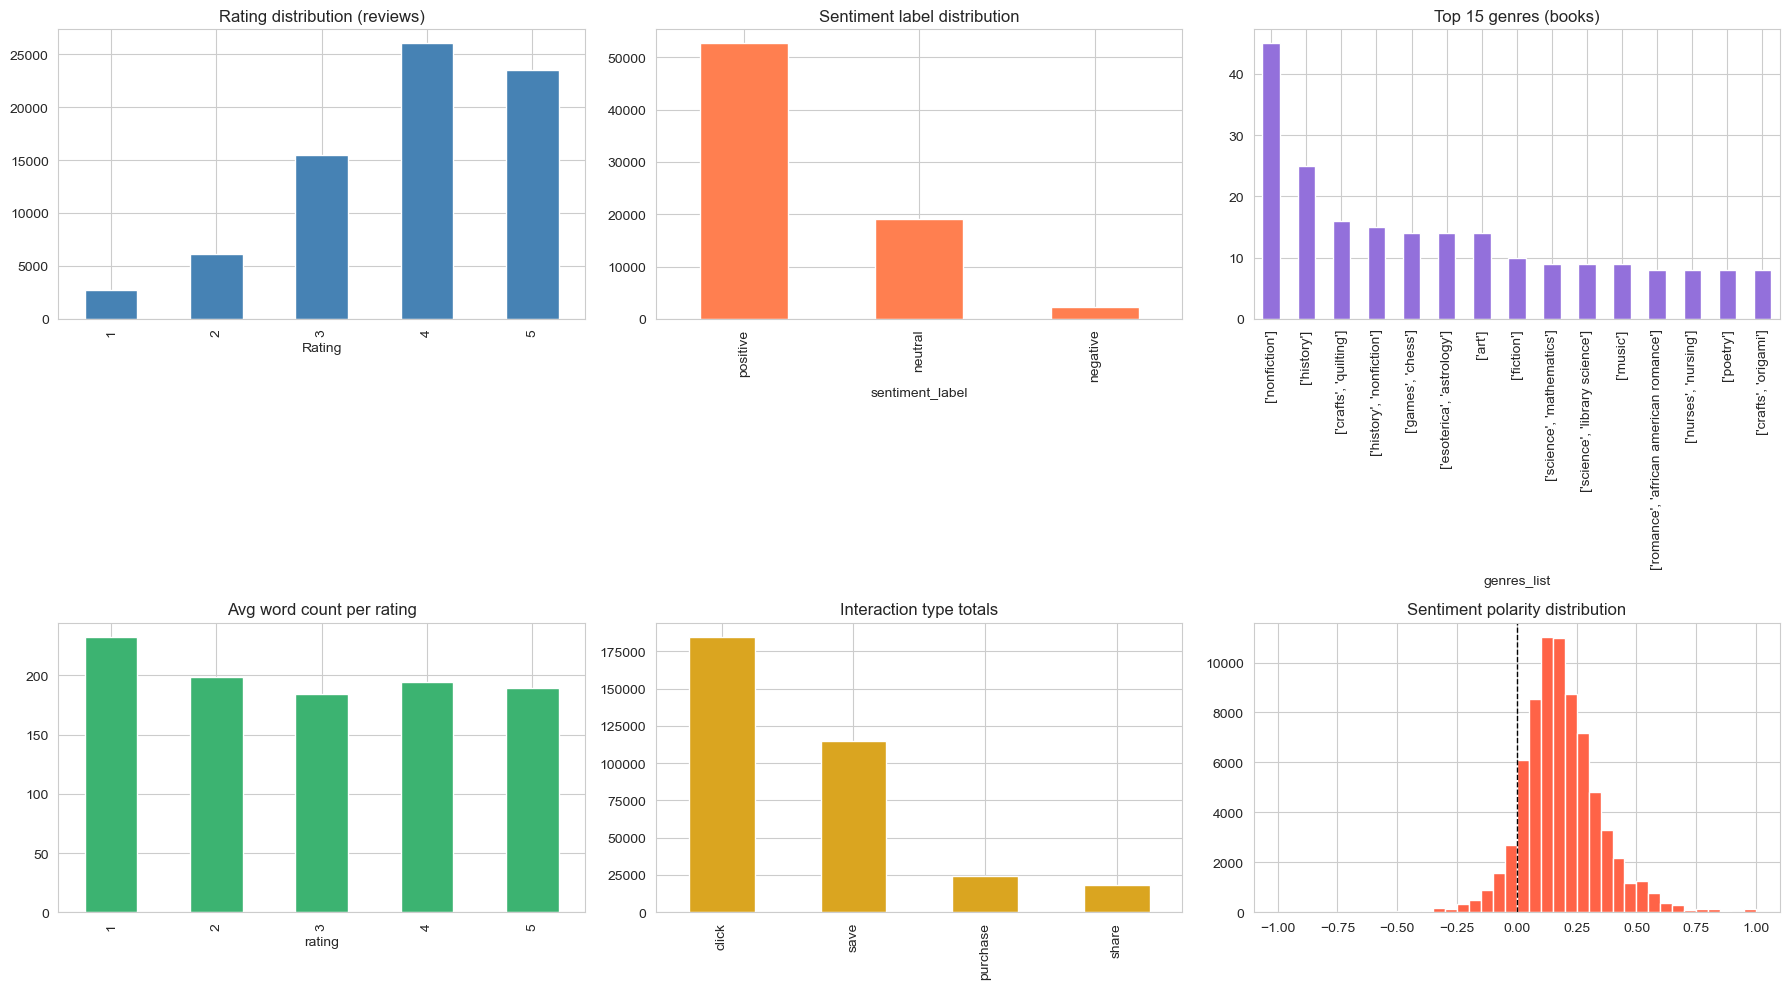

Unique books  (reviews):      5,502
Unique books  (books table):  6,000
Unique users  (reviews):      33,643
Unique users  (interactions): 33,643


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

reviews["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Rating distribution (reviews)"); axes[0, 0].set_xlabel("Rating")

if "sentiment_label" in reviews.columns:
    reviews["sentiment_label"].value_counts().plot(
        kind="bar", ax=axes[0, 1], color="coral")
    axes[0, 1].set_title("Sentiment label distribution")

if "genres_list" in books.columns:
    books["genres_list"].str.split("|").explode()        .value_counts().head(15).plot(kind="bar", ax=axes[0, 2], color="mediumpurple")
    axes[0, 2].set_title("Top 15 genres (books)")

if "word_count" in reviews.columns:
    reviews.groupby("rating")["word_count"].mean().plot(
        kind="bar", ax=axes[1, 0], color="mediumseagreen")
    axes[1, 0].set_title("Avg word count per rating")

int_cols = [c for c in ["click", "save", "purchase", "share"] if c in interactions.columns]
interactions[int_cols].sum().plot(kind="bar", ax=axes[1, 1], color="goldenrod")
axes[1, 1].set_title("Interaction type totals")

if "sentiment_polarity" in reviews.columns:
    reviews["sentiment_polarity"].hist(bins=40, ax=axes[1, 2], color="tomato")
    axes[1, 2].set_title("Sentiment polarity distribution")
    axes[1, 2].axvline(0, color="black", linestyle="--", linewidth=1)

plt.tight_layout(); plt.show()
print(f"Unique books  (reviews):      {reviews['book_id'].nunique():,}")
print(f"Unique books  (books table):  {books['book_id'].nunique():,}")
print(f"Unique users  (reviews):      {reviews['user_id'].nunique():,}")
print(f"Unique users  (interactions): {interactions['user_id'].nunique():,}")


**2.4. Filter reviews & merge book metadata**

In [11]:
before = len(reviews)
mask   = reviews["rating"] > 0
if "is_spam_flag"   in reviews.columns: mask &= (reviews["is_spam_flag"]   == False)
if "is_boilerplate" in reviews.columns: mask &= (reviews["is_boilerplate"] == False)

df_clean = reviews[mask].copy()
print(f"Reviews: {before:,} → {len(df_clean):,}  ({before - len(df_clean):,} removed)")

books_meta = books[["book_id", "genres_list", "desc_clean", "author_clean"]]    .drop_duplicates("book_id")
df_clean = df_clean.merge(books_meta, on="book_id", how="left")
print(f"Matched to book metadata: {df_clean['genres_list'].notna().sum():,} / {len(df_clean):,}")


Reviews: 73,911 → 72,660  (1,251 removed)
Matched to book metadata: 72,660 / 72,660


**2.5. Build book profiles & TF-IDF keyword extraction**

In [12]:
# ── Aggregate reviews per book ────────────────────────────────────────────
agg = df_clean.groupby("book_id").agg(
    review_text  = ("review_normalized", lambda x: " ".join(x.astype(str))),
    genres_list  = ("genres_list",       "first"),
    desc_clean   = ("desc_clean",        "first"),
    author_clean = ("author_clean",      "first"),
    title        = ("title",             "first"),
).reset_index()

# Include books with no reviews (metadata only)
missing = books[["book_id", "title", "genres_list", "desc_clean", "author_clean"]]    [~books["book_id"].isin(agg["book_id"])].copy()
missing["review_text"] = ""
book_profiles = pd.concat([agg, missing], ignore_index=True)
print(f"Total book profiles: {len(book_profiles):,}")


Total book profiles: 6,000


In [13]:
# ── TF-IDF: keyword extraction + KMeans clustering only ──────────────────
# NOT used for similarity search (SentenceTransformer handles that)
combined_text = (
    book_profiles["review_text"] + " " + book_profiles["desc_clean"].fillna("")
)
tfidf = TfidfVectorizer(max_features=6000, min_df=2, max_df=0.85, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(combined_text.fillna(""))
print(f"TF-IDF matrix: {tfidf_matrix.shape}  (for keywords + clustering only)")

feature_names = np.array(tfidf.get_feature_names_out())

def get_top_keywords(book_idx: int, top_n: int = 15) -> list:
    row = tfidf_matrix[book_idx].toarray().flatten()
    return feature_names[row.argsort()[::-1][:top_n]].tolist()

print("Extracting top keywords per book...")
book_profiles["top_keywords"] = [get_top_keywords(i) for i in range(len(book_profiles))]
print("Sample:")
print(book_profiles[["title", "top_keywords"]].head(3))


TF-IDF matrix: (6000, 6000)  (for keywords + clustering only)
Extracting top keywords per book...
Sample:
                                               title  \
0  who is that man?: in search of the real bob dylan   
1  all the fun's in how you say a thing: an expla...   
2    the greatest inventions of the past 2,000 years   

                                        top_keywords  
0  [dylan, bob, song, music, album, david, biogra...  
1  [poetry, poet, english, poem, rhyme, verse, li...  
2  [invention, printing, internet, option, editor...  


**2.6. Genre parsing & KMeans trope clustering**

In [14]:
# ── Genre parsing ─────────────────────────────────────────────────────────
book_profiles["genres_list"]   = book_profiles["genres_list"].apply(parse_genres)
book_profiles["genre_primary"] = book_profiles["genres_list"].apply(
    lambda lst: lst[0] if lst else None
)

combined_fallback = book_profiles["review_text"].fillna("") + " " + book_profiles["desc_clean"].fillna("")
missing_mask = book_profiles["genre_primary"].isna()
book_profiles.loc[missing_mask, "genre_primary"] =     combined_fallback[missing_mask].apply(classify_genre_fallback)

all_tags = [t for lst in book_profiles["genres_list"] for t in lst]
tag_counts = Counter(all_tags)
print(f"Unique genre tags: {len(tag_counts):,}")
print(f"Books with real genre: {(~missing_mask).sum():,} | fallback: {missing_mask.sum():,}")
print("\nTop 20 tags:")
for tag, cnt in tag_counts.most_common(20):
    print(f"  {cnt:>5}  {tag}")


Unique genre tags: 5,414
Books with real genre: 5,990 | fallback: 10

Top 20 tags:
     45  nonfiction
     25  history
     16  crafts quilting
     15  history nonfiction
     14  art
     14  games chess
     14  esoterica astrology
      9  science library science
      9  music
      9  science mathematics
      8  nurses nursing
      8  romance african american romance
      8  philosophy
      8  poetry
      8  crafts origami
      7  aviation
      7  combat martial arts
      6  occult tarot
      6  crafts quilting art
      6  museology museums


In [15]:
# ── KMeans trope clustering (notebook STEP 12b) ───────────────────────────
if "trope_cluster" not in book_profiles.columns:
    print("Running KMeans clustering...")
    _svd = TruncatedSVD(n_components=100, random_state=42)
    _X   = _svd.fit_transform(tfidf_matrix)
    _km  = KMeans(n_clusters=60, random_state=42, n_init=10)
    book_profiles["trope_cluster"] = _km.fit_predict(_X)
    print("Done.")

CLUSTER_LABEL_MAP = {
     0: "anthology and short stories",  1: None,
     2: "design and architecture",       3: "superhero comics",
     4: "family drama",                  5: None,
     6: "historical romance",            7: "epic fantasy",
     8: "fairy tale retelling",          9: "poetry collection",
    10: None,                           11: None,
    12: "sports story",                 13: "asian history and culture",
    14: "cookbook and food",            15: "relationships and sexuality",
    16: "self-help guide",             17: None,
    18: "manga",                        19: "christian and religious fiction",
    20: "personal development",         21: "world war military history",
    22: "american political history",   23: None,
    24: "nature and wildlife",          25: "graphic novel and comics",
    26: "crafts and hobbies",           27: "science and nature for kids",
    28: "civil war history",            29: "jewish history and culture",
    30: "holiday and seasonal",         31: "biblical commentary",
    32: "children's picture book",      33: None,
    34: "quilting and sewing",          35: "film and cinema",
    36: "animals and nature",           37: "russian and soviet history",
    38: "pets and animal care",         39: "mathematics and textbook",
    40: "murder mystery detective",     41: None,
    42: "contemporary romance",         43: "art and visual culture",
    44: "literary fiction",             45: "health diet and nutrition",
    46: "business and management",      47: "pirates and nautical adventure",
    48: "language and linguistics",     49: "royalty and medieval kingdom",
    50: "amish and community fiction",  51: "ancient egypt and classics",
    52: "tudor and british history",    53: "manga romance",
    54: "theatre and plays",            55: "how-to guide and reference",
    56: "prayer and devotional",        57: "japanese history and culture",
    58: "roman and ancient history",    59: "physics and philosophy of science",
}

book_profiles["mined_trope"] = book_profiles["trope_cluster"].map(CLUSTER_LABEL_MAP)
print(f"Trope labels assigned: {book_profiles['mined_trope'].notna().sum():,}")


Running KMeans clustering...
Done.
Trope labels assigned: 5,219


**2.7. Dual Embedding: desc_emb + review_emb (new in v3)**

**Why dual?** Description captures the book's *actual content*; reviews capture the *reader's vocabulary*.  
Similarity = `0.7 × desc_emb + 0.3 × review_emb` (L2-normalised before combining).  
Embeddings are saved as `.npy` for fast reload.


In [16]:
# ── Separate clean columns ────────────────────────────────────────────────
book_profiles["description_clean"] = book_profiles["desc_clean"].fillna("").astype(str)
book_profiles["review_clean_text"] = book_profiles["review_text"].fillna("").astype(str)

print(f"description_clean non-empty: {(book_profiles['description_clean'] != '').sum():,}")
print(f"review_clean_text non-empty: {(book_profiles['review_clean_text'] != '').sum():,}")

# ── Encode description (L2-normalised) ───────────────────────────────────
print("\nEncoding desc_emb (~1 min)...")
desc_emb = sk_normalize(
    model.encode(
        book_profiles["description_clean"].tolist(),
        batch_size=64, show_progress_bar=True, convert_to_numpy=True
    ), norm="l2"
)

# ── Encode reviews (L2-normalised) ───────────────────────────────────────
print("\nEncoding review_emb (~1-2 min)...")
review_emb = sk_normalize(
    model.encode(
        book_profiles["review_clean_text"].tolist(),
        batch_size=64, show_progress_bar=True, convert_to_numpy=True
    ), norm="l2"
)

np.save("desc_emb.npy",   desc_emb)
np.save("review_emb.npy", review_emb)
print(f"\n[✓] desc_emb:   {desc_emb.shape}  → saved desc_emb.npy")
print(f"[✓] review_emb: {review_emb.shape} → saved review_emb.npy")

assert abs(np.linalg.norm(desc_emb[0])   - 1.0) < 1e-5, "desc_emb not normalised!"
assert abs(np.linalg.norm(review_emb[0]) - 1.0) < 1e-5, "review_emb not normalised!"
print("[✓] Normalisation check PASSED")


description_clean non-empty: 6,000
review_clean_text non-empty: 5,502

Encoding desc_emb (~1 min)...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]


Encoding review_emb (~1-2 min)...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]


[✓] desc_emb:   (6000, 384)  → saved desc_emb.npy
[✓] review_emb: (6000, 384) → saved review_emb.npy
[✓] Normalisation check PASSED


In [17]:
# ── Reload from .npy if you restart kernel (skips re-encoding) ───────────
# desc_emb   = sk_normalize(np.load("desc_emb.npy"),   norm="l2")
# review_emb = sk_normalize(np.load("review_emb.npy"), norm="l2")

# ── Core pipeline functions (notebook STEP 8) ─────────────────────────────
def process_query(query: str) -> np.ndarray:
    """Clean query → encode → L2-normalise → numpy (1, 384)."""
    q = re.sub(r"[^a-z0-9\s]", "", str(query).lower())
    q = re.sub(r"\s+", " ", q).strip()
    return sk_normalize(model.encode([q], convert_to_numpy=True), norm="l2")


def compute_similarity(query_vec: np.ndarray,
                        desc_emb:   np.ndarray,
                        review_emb: np.ndarray,
                        desc_weight:   float = 0.7,
                        review_weight: float = 0.3) -> np.ndarray:
    """Weighted cosine: 0.7*desc + 0.3*review → numpy (N,)."""
    return (desc_weight   * np.dot(query_vec, desc_emb.T)[0] +
            review_weight * np.dot(query_vec, review_emb.T)[0])


def get_top_k(scores: np.ndarray, k: int = 10) -> np.ndarray:
    """Top-k indices by score descending."""
    return np.argsort(scores)[::-1][:k]

print("[✓] process_query / compute_similarity / get_top_k defined")


[✓] process_query / compute_similarity / get_top_k defined


In [18]:
def extract_intent_final(query: str, model=None, trope_embeddings=None) -> dict:
    """
    Negation-aware intent extractor (v4.0++ - production lite).
    **IMPROVED (v4.0++):** Better pattern detection + auto-semantic filtering
    - Fixed: Extract negated word itself (not just after cue)
    - Fixed: Look ahead up to 5 words for negated patterns
    - Fixed: Exclude negated words from positive keywords
    """
    from sentence_transformers import util as st_util
    import torch
    
    query_lower = normalize_query(query)
    words = query_lower.split()
    negated_idx = _get_negated_indices_simple(query_lower)

    # ── IMPROVED: Better negated word extraction (look ahead 5 words) ────────
    negated_words = []
    for i, w in enumerate(words):
        if w in NEGATION_CUES:
            # Look up to 5 words ahead (not just 3-4)
            for j in range(i + 1, min(i + 6, len(words))):
                w_next = words[j]
                # Stop at conjunctions
                if w_next in ("but", "and", "or", "although"):
                    break
                # Capture content words
                if len(w_next) > 2 and w_next not in NEGATION_CUES and w_next not in KEYWORD_BLACKLIST:
                    negated_words.append(w_next)
                    break
    
    # Auto-detect negated themes using semantic similarity
    negated_theme_keywords = set()
    if model is not None and trope_embeddings is not None:
        for neg_word in set(negated_words):
            try:
                neg_emb = model.encode(f"not {neg_word}", convert_to_tensor=True)
                trope_scores_neg = st_util.cos_sim(neg_emb, trope_embeddings)[0]
                top_indices = torch.topk(trope_scores_neg, min(5, len(TROPE_LABELS))).indices
                nearby_tropes = [TROPE_LABELS[i] for i in top_indices.cpu().numpy()]
                
                # Keep only tropes that contain the negated word
                related = [t for t in nearby_tropes if neg_word in t.lower()]
                negated_theme_keywords.update(related)
            except:
                pass

    # ── FIXED: Keyword extraction - EXCLUDE negated words ──────────────────
    positive_kws, negative_kws = [], []
    processed = set()
    
    for i, w in enumerate(words):
        if i in processed:
            continue
        if w in NEGATION_CUES or w in KEYWORD_BLACKLIST:
            continue
        if len(w) <= 2:
            continue
        
        # Multi-word concepts
        multi_word = None
        if i + 1 < len(words):
            next_word = words[i + 1]
            if (next_word not in KEYWORD_BLACKLIST and 
                next_word not in NEGATION_CUES and 
                len(next_word) > 2):
                multi_word = f"{w} {next_word}"
                processed.add(i + 1)
        
        is_negated = i in negated_idx
        keyword = multi_word if multi_word else w
        
        # ← FIXED: Don't include negated words in positive keywords
        if is_negated:
            negative_kws.append(f"not_{keyword.replace(' ', '_')}")
        else:
            positive_kws.append(keyword)

    # ── Trope matching (with negation filtering) ───────────────────────────
    tropes = []
    for trope, keywords in TROPE_KEYWORDS.items():
        triggered = [kw for kw in keywords if kw in query_lower]
        if triggered:
            all_neg = all(
                any(w in kw for w_i, w in enumerate(words) if w_i in negated_idx)
                for kw in triggered
            )
            if not all_neg:
                tropes.append(trope)
    
    # Filter tropes using auto-detected negated themes (NO hardcoded mapping!)
    tropes = [
        t for t in tropes 
        if not any(kw in t.lower() for kw in negated_theme_keywords)
    ]

    # Tone matching
    tones = []
    for tone, keywords in TONE_KEYWORDS.items():
        if any(kw in query_lower for kw in keywords):
            tones.append(tone)

    # Genre detection
    genres = []
    for genre, keywords in GENRE_KEYWORDS.items():
        if sum(1 for kw in keywords if kw in query_lower) >= 1:
            genres.append(genre)

    return {
        "original_query": query,
        "keywords": positive_kws,
        "negative_keywords": negative_kws,
        "tropes": tropes,
        "tones": tones,
        "genres": genres,
    }

In [19]:
def remove_negated_base_tropes(query: str, tropes: list) -> list:
    """
    Post-processor for negation handling.
    Extracts negated words from query and removes any tropes that match.
    Uses bidirectional substring matching and smart word extraction.
    
    Example: query="not romance" → removes any trope containing "romance"
    """
    query_lower = query.lower()
    
    # Words to skip when extracting negated content
    skip_words = {"a", "an", "the", "any", "some", "all", "this", "that", "these", "those"}
    
    # Extract negated words via regex patterns with lookahead to skip articles
    negated_words = set()
    
    # Extended patterns that capture the negated concept, not just articles
    patterns = [
        r'not\s+(?:a\s+|an\s+|the\s+)?(\w+)',
        r'no\s+(?:a\s+|an\s+|the\s+)?(\w+)',
        r'without\s+(?:a\s+|an\s+|the\s+)?(?:any\s+)?(\w+)',
        r'definitely\s+not\s+(?:a\s+|an\s+|the\s+)?(\w+)',
        r'never\s+(?:a\s+|an\s+|the\s+)?(\w+)',
    ]
    
    for pattern in patterns:
        matches = re.findall(pattern, query_lower)
        negated_words.update(m for m in matches if m not in skip_words)
    
    # If no negated words found, return original tropes
    if not negated_words:
        return tropes
    
    # Filter tropes using bidirectional substring matching
    # Also check if underscores versions match (e.g., "science_fiction")
    filtered_tropes = []
    for trope in tropes:
        trope_lower = trope.lower()
        trope_underscored = trope_lower.replace(" ", "_")  # Handle space-separated tropes
        
        # Keep trope only if NO negated word matches it (bidirectional)
        is_negated = any(
            (neg_word in trope_lower or trope_lower in neg_word or
             neg_word in trope_underscored or trope_underscored in neg_word)
            for neg_word in negated_words
        )
        
        if not is_negated:
            filtered_tropes.append(trope)
    
    return filtered_tropes

In [20]:
print("=" * 90)
print("CRITICAL TESTS: Negation-Aware Intent Extraction")
print("=" * 90)

critical_tests = [
    ("'A story with a strong friendship but definitely not a romance.'",
     "Should: Genres=(none), Tropes=['friendship'], no romance"),
    
    ("'I want a book without any magic but it must have dragons.'",
     "Should: Genres=['fantasy'], no magic trope (it's negated)"),
    
    ("'Books where the main character does not die at the end and finds happiness.'",
     "Should: Extract 'dies' negation and 'happiness' (if keywords exist)"),
]

test_queries = [q for q, _ in critical_tests]

for i, (q_desc, expected) in enumerate(critical_tests, 1):
    q = test_queries[i-1]
    r = extract_intent_final(q)
    
    print(f"\n[Test #{i}] {q_desc}")
    print(f"Expected: {expected}")
    print(f"Result:")
    print(f"  Genres  : {r['genres'] if r['genres'] else '(none)'}")
    print(f"  Tropes  : {r['tropes'] if r['tropes'] else '(none)'}")
    print(f"  Tones   : {r['tones'] if r['tones'] else '(none)'}")


CRITICAL TESTS: Negation-Aware Intent Extraction

[Test #1] 'A story with a strong friendship but definitely not a romance.'
Expected: Should: Genres=(none), Tropes=['friendship'], no romance
Result:
  Genres  : ['romance']
  Tropes  : ['romance', 'friendship']
  Tones   : (none)

[Test #2] 'I want a book without any magic but it must have dragons.'
Expected: Should: Genres=['fantasy'], no magic trope (it's negated)
Result:
  Genres  : ['fantasy']
  Tropes  : (none)
  Tones   : (none)

[Test #3] 'Books where the main character does not die at the end and finds happiness.'
Expected: Should: Extract 'dies' negation and 'happiness' (if keywords exist)
Result:
  Genres  : (none)
  Tropes  : (none)
  Tones   : (none)


**2.8. Sentiment aggregation per book**

In [21]:
sentiment_agg = df_clean.groupby("book_id").agg(
    avg_polarity     = ("sentiment_polarity",    "mean"),
    avg_subjectivity = ("sentiment_subjectivity","mean"),
    liked_ratio      = ("liked",                 "mean"),
    rating_norm_mean = ("rating",            "mean"),
).reset_index().round(4)

dominant_sentiment = (
    df_clean.groupby("book_id")["sentiment_label"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={"sentiment_label": "dominant_sentiment"})
)
sentiment_agg = sentiment_agg.merge(dominant_sentiment, on="book_id", how="left")

print(f"Sentiment aggregated for {len(sentiment_agg):,} books")
print(sentiment_agg.head(3))
print("\nDominant sentiment distribution:")
print(sentiment_agg["dominant_sentiment"].value_counts())


Sentiment aggregated for 5,502 books
  book_id  avg_polarity  avg_subjectivity  liked_ratio  rating_norm_mean  \
0   10010        0.1865            0.5283       0.8000            3.7333   
1   10019        0.2755            0.5363       0.7647            4.0588   
2   10028        0.2190            0.4516       0.3333            3.6667   

  dominant_sentiment  
0           positive  
1           positive  
2           positive  

Dominant sentiment distribution:
dominant_sentiment
positive    4649
neutral      804
negative      49
Name: count, dtype: int64


Sentiment data from individual reviews is aggregated at the book level to construct structured features for downstream recommendation tasks. The dataset is grouped by book_id to compute key metrics including:
- Average sentiment polarity to capture overall emotional tone
- Average subjectivity to indicate the degree of opinion-based content
- Liked ratio to indicate the proportion of positive user feedbac
- Mean normalized rating

## Phase 2: Collaborative Composite Score

$$\text{collab\_score} = 0.5 \times \text{bayesian\_score} + 0.3 \times \text{interaction\_score} + 0.2 \times \text{sentiment\_score}$$

> **Bayesian score** uses `rating` and `reviews` (= totalratings) columns from **`6000_bookssamples.csv`** — these are the canonical Goodreads aggregate values, not per-review averages.

| Sub-score | Weight | Source fields |
|---|---|---|
| **bayesian_score** | 0.5 | `books.rating`, `books.reviews` (6000_books) |
| **interaction_score** | 0.3 | `save`, `click`, `search`, `purchase`, `share` (interactions) |
| **sentiment_score** | 0.2 | `sentiment_polarity`, `1−sentiment_subjectivity` (reviews) |


In [22]:
print("=== CLEANING BOOK_ID COLUMN ===")
print(f"Before: {interactions['book_id'].nunique()} unique values, {(interactions['book_id'] == 'nan').sum():,} string 'nan' values")

# Convert string 'nan' to actual NaN, then drop those rows
interactions['book_id'] = interactions['book_id'].replace('nan', np.nan)
interactions = interactions[interactions['book_id'].notna()].copy()

print(f"After:  {interactions['book_id'].nunique()} unique values, {len(interactions):,} rows remaining")
print(f"\nSample book_ids (first 10 unique):")
print(interactions['book_id'].unique()[:10])

print(f"\nAll interaction signals (save/click/purchase/share) after cleanup:")
sig_cols = ['save', 'click', 'purchase', 'share']
for col in sig_cols:
    if col in interactions.columns:
        print(f"  {col}: sum={interactions[col].sum():,}")


=== CLEANING BOOK_ID COLUMN ===
Before: 6001 unique values, 33,643 string 'nan' values
After:  6000 unique values, 416,048 rows remaining

Sample book_ids (first 10 unique):
['32380.0' '39560.0' '50952.0' '38278.0' '18481.0' '50817.0' '47808.0'
 '34308.0' '8269.0' '8828.0']

All interaction signals (save/click/purchase/share) after cleanup:
  save: sum=114,776
  click: sum=184,805
  purchase: sum=24,437
  share: sum=18,119


In [23]:
# ── Convert both to consistent string format ──────────────────────────────
# interactions book_ids: '32380.0' → '32380' (convert to int first, then str)
# books book_ids: '20385' → already clean

# For interactions: convert to numeric, then to int, then to string
interactions['book_id'] = pd.to_numeric(interactions['book_id'], errors='coerce').fillna(0).astype(int).astype(str)
books['book_id'] = books['book_id'].astype(str)

print("=== FORMAT ALIGNMENT ===")
print(f"Interactions book_id samples (after format fix): {interactions['book_id'].unique()[:5]}")
print(f"Books book_id samples:                           {books['book_id'].unique()[:5]}")

# Check overlap
int_ids = set(interactions['book_id'].unique())
book_ids_set = set(books['book_id'].unique())
overlap = int_ids & book_ids_set

print(f"\nOverlap analysis:")
print(f"  Interactions unique book_ids: {len(int_ids):,}")
print(f"  Books unique book_ids:        {len(book_ids_set):,}")
print(f"  Overlap: {len(overlap):,} ({100*len(overlap)/len(book_ids_set):.1f}% of books)")

# Remove rows where book_id is '0' (was NaN)
before_filter = len(interactions)
interactions = interactions[interactions['book_id'] != '0'].copy()
print(f"\nFiltered out {before_filter - len(interactions):,} rows with book_id='0'")


=== FORMAT ALIGNMENT ===
Interactions book_id samples (after format fix): ['32380' '39560' '50952' '38278' '18481']
Books book_id samples:                           ['20385' '17418' '3525' '6740' '4745']

Overlap analysis:
  Interactions unique book_ids: 6,000
  Books unique book_ids:        6,000
  Overlap: 6,000 (100.0% of books)

Filtered out 0 rows with book_id='0'


In [24]:
interactions["book_id"] = interactions["book_id"].astype(str)
books["book_id"]        = books["book_id"].astype(str)

# ── Source: rating + totalratings from 6000_bookssamples.csv ─────────────
# books.rating  = Goodreads avg rating   (more reliable than review_clean agg)
# books.reviews = totalratings count     (used as n in Bayesian formula)
books_rating = books[["book_id", "rating", "reviews"]].copy()
books_rating.columns = ["book_id", "rating", "totalratings"]
books_rating["rating"]   = pd.to_numeric(books_rating["rating"],   errors="coerce")
books_rating["totalratings"] = pd.to_numeric(books_rating["totalratings"], errors="coerce")

print(f"Books with rating data:  {books_rating['rating'].notna().sum():,} / {len(books_rating):,}")
print(f"Rating range:   {books_rating['rating'].min():.2f} – {books_rating['rating'].max():.2f}")
print(f"Reviews range:  {books_rating['totalratings'].min():.0f} – {books_rating['totalratings'].max():.0f}")

# ── Interaction signals per book ──────────────────────────────────────────
# Aggregate save / click / purchase / share from interaction.csv
int_agg = interactions.groupby("book_id").agg(
    total_saves     = ("save",     "sum"),
    total_clicks    = ("click",    "sum"),
    total_purchases = ("purchase", "sum"),
    total_shares    = ("share",    "sum"),
).reset_index()

# Search count: robust filter handles both numeric 0 / 0.0 and string "0"
_search_col = pd.to_numeric(interactions["search"], errors="coerce").fillna(0)
search_counts = (
    interactions[_search_col != 0]
    .groupby("book_id").size()
    .reset_index(name="search_count")
)

print(f"\nBooks with interaction data: {len(int_agg):,}")
print(f"Books with search events:    {len(search_counts):,}")

# Sanity check — confirm book_id types match before merge
print(f"\nbook_id dtype check — books_rating: {books_rating['book_id'].dtype}, "
      f"int_agg: {int_agg['book_id'].dtype}")

# ── Merge all signals ─────────────────────────────────────────────────────
collab_raw = (
    books_rating
    .merge(int_agg,       on="book_id", how="left")
    .merge(search_counts, on="book_id", how="left")
    .merge(sentiment_agg[["book_id", "avg_polarity", "avg_subjectivity"]],
           on="book_id", how="left")
)

collab_raw.fillna({
    "total_saves": 0, "total_clicks": 0, "total_purchases": 0,
    "total_shares": 0, "search_count": 0,
    "avg_polarity": 0.0, "avg_subjectivity": 0.5,
}, inplace=True)

# Verify interaction columns are non-trivial after merge
_int_check = collab_raw[["total_saves","total_clicks","total_purchases","total_shares","search_count"]]
print(f"\nInteraction column sums (should be > 0 if data exists):")
print(_int_check.sum().to_string())
if _int_check.sum().sum() == 0:
    print("\n[WARN] All interaction values are 0. Check that interactions.csv "
          "book_id values overlap with 6000_bookssamples.csv book_id values.")
    print("Sample interactions book_ids:", interactions["book_id"].head(5).tolist())
    print("Sample books book_ids:       ", books_rating["book_id"].head(5).tolist())

scaler = MinMaxScaler()

# ── Sub-score 1: Bayesian Score ───────────────────────────────────────────
# Formula: (C*m + avg_rating*n) / (m + n)
# C = global mean rating; m = 50 (conservative prior)
C = collab_raw["rating"].dropna().mean()
m = 50
collab_raw["totalratings"] = collab_raw["totalratings"].fillna(0)
collab_raw["rating"]   = collab_raw["rating"].fillna(C)

collab_raw["raw_bayesian"] = (
    (C * m + collab_raw["rating"] * collab_raw["totalratings"]) /
    (m + collab_raw["totalratings"])
)
collab_raw["bayesian_score"] = scaler.fit_transform(
    collab_raw[["raw_bayesian"]]
).flatten().round(4)

# ── Sub-score 2: Interaction Score ────────────────────────────────────────
# Weights: purchase=0.35, save=0.25, share=0.20, click=0.10, search=0.10
INT_FEATURES = ["total_purchases", "total_saves", "total_shares",
                "total_clicks",    "search_count"]
INT_WEIGHTS  = np.array([0.35, 0.25, 0.20, 0.10, 0.10])

int_data = collab_raw[INT_FEATURES].fillna(0)

# Guard: if ALL values are 0 (no book_id overlap), fall back to 0 and warn
if int_data.sum().sum() == 0:
    print("[WARN] interaction_score: no overlap found — set to 0.0")
    collab_raw["interaction_score"] = 0.0
else:
    int_scaled = scaler.fit_transform(int_data)
    raw_int    = (int_scaled * INT_WEIGHTS).sum(axis=1)
    mn, mx     = raw_int.min(), raw_int.max()
    collab_raw["interaction_score"] = ((raw_int - mn) / (mx - mn + 1e-9)).round(4)

# ── Sub-score 3: Sentiment Score ──────────────────────────────────────────
# objectivity = 1 − subjectivity (less subjective → more credible reviews)
collab_raw["objectivity"] = (1 - collab_raw["avg_subjectivity"]).round(4)
SENT_FEATURES = ["avg_polarity", "objectivity"]
SENT_WEIGHTS  = np.array([0.65, 0.35])
sent_scaled   = scaler.fit_transform(collab_raw[SENT_FEATURES].fillna(0))
raw_sent      = (sent_scaled * SENT_WEIGHTS).sum(axis=1)
mn, mx        = raw_sent.min(), raw_sent.max()
collab_raw["sentiment_score"] = ((raw_sent - mn) / (mx - mn + 1e-9)).round(4)

# ── Composite collab_score ────────────────────────────────────────────────
collab_raw["collab_score"] = (
    0.5 * collab_raw["bayesian_score"]    +
    0.3 * collab_raw["interaction_score"] +
    0.2 * collab_raw["sentiment_score"]
).round(4)

mn, mx = collab_raw["collab_score"].min(), collab_raw["collab_score"].max()
collab_raw["collab_score"] = ((collab_raw["collab_score"] - mn) / (mx - mn + 1e-9)).round(4)

collab_scores = collab_raw[[
    "book_id", "collab_score", "bayesian_score",
    "interaction_score", "sentiment_score",
    "rating", "totalratings",
]].set_index("book_id")

print(f"\n[✓] Collab scores for {len(collab_scores):,} books")
print(collab_scores[["collab_score","bayesian_score","interaction_score","sentiment_score"]]
      .describe().round(3))


Books with rating data:  6,000 / 6,000
Rating range:   0.00 – 5.00
Reviews range:  0 – 57133

Books with interaction data: 6,000
Books with search events:    0

book_id dtype check — books_rating: object, int_agg: object

Interaction column sums (should be > 0 if data exists):
total_saves        114776.0
total_clicks       184805.0
total_purchases     24437.0
total_shares        18119.0
search_count            0.0

[✓] Collab scores for 6,000 books
       collab_score  bayesian_score  interaction_score  sentiment_score
count      6000.000        6000.000           6000.000         6000.000
mean          0.460           0.606              0.304            0.549
std           0.138           0.071              0.213            0.047
min           0.000           0.000              0.000            0.000
25%           0.354           0.583              0.108            0.524
50%           0.428           0.602              0.281            0.553
75%           0.544           0.628        

In this phase, a collaborative composite score is constructed to combine multiple user-driven signals into a unified ranking metric for each book. The score integrates three components: 
- A Bayesian score (weight = 0.5) based on average rating and total ratings to ensure statistical reliability
- An interaction score (weight = 0.3) derived from user behaviors such as purchases, saves, shares, and clicks to capture engagement intensity
- A sentiment score (weight = 0.2) computed from review polarity and objectivity to reflect both emotional tone and credibility.

All components are normalized using Min-Max scaling before aggregation, and the final score is re-scaled to a [0,1] range to ensure comparability across 6,000 books. Overall, this composite approach balances popularity, behavior, and sentiment, producing a more robust and reliable recommendation signal than single-source methods.

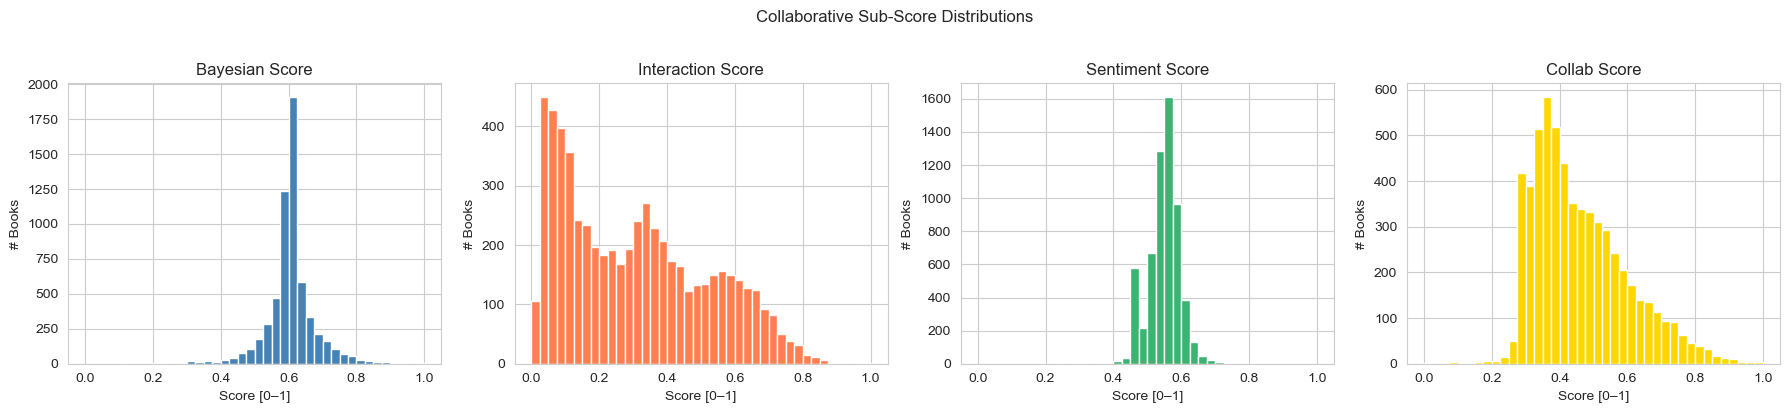

In [25]:
# ── Sub-score distribution visualisation ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
labels = ["bayesian_score", "interaction_score", "sentiment_score", "collab_score"]
colors = ["steelblue", "coral", "mediumseagreen", "gold"]
for ax, col, color in zip(axes, labels, colors):
    collab_scores[col].hist(bins=40, ax=ax, color=color, edgecolor="white")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Score [0–1]"); ax.set_ylabel("# Books")
plt.suptitle("Collaborative Sub-Score Distributions", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()


The Bayesian score is tightly centered around ~0.6, indicating stable rating-based quality due to smoothing. The interaction score shows wider dispersion, capturing variability in user engagement and contributing most to differentiation. In contrast, the sentiment score is narrowly concentrated, reflecting limited variance and a general positive bias. The final collaborative score achieves a balanced spread, confirming that combining these signals improves both stability and ranking discrimination.

**3.1. User profiles & user-item matrix**

In [26]:
counts    = df_clean.groupby("user_id")["book_id"].count()
active    = counts[counts >= 3].index
df_active = df_clean[df_clean["user_id"].isin(active)].copy()
print(f"Active users (≥3 reviews): {len(active):,}")
print(f"Reviews from active users: {len(df_active):,}")

user_item_matrix = df_active.pivot_table(
    index="user_id", columns="book_id", values="rating_norm"
)
sparsity = user_item_matrix.isnull().sum().sum() / user_item_matrix.size
print(f"User-item matrix: {user_item_matrix.shape}  |  Sparsity: {sparsity:.1%}")

matrix_filled = user_item_matrix.fillna(0)
user_sim = pd.DataFrame(
    cosine_similarity(matrix_filled),
    index=user_item_matrix.index,
    columns=user_item_matrix.index,
)

user_texts = (
    df_active.groupby("user_id")["review_normalized"]
    .apply(lambda x: " ".join(x.astype(str)))
    .to_dict()
)
user_read = df_clean.groupby("user_id")["book_id"].apply(set).to_dict()

print(f"[✓] User similarity matrix: {user_sim.shape}")
print(f"[✓] User taste profiles:    {len(user_texts):,}")


Active users (≥3 reviews): 3,938
Reviews from active users: 39,647
User-item matrix: (3938, 5090)  |  Sparsity: 99.8%
[✓] User similarity matrix: (3938, 3938)
[✓] User taste profiles:    3,938


This step focuses on constructing the **user-based collaborative filtering foundation**, enabling the system to capture preference patterns beyond item-level features. First, users with at least three reviews are selected to ensure sufficient behavioral data, resulting in 3,938 active users and 39,647 interactions. From this, a user–item matrix is built using normalized ratings, with a sparsity of 99.8%, which is typical in recommendation systems and highlights the need for similarity-based inference.

To address this sparsity, missing values are filled and a **user similarity matrix** is computed using cosine similarity, allowing the system to identify users with similar preferences. In parallel, user taste profiles are constructed by aggregating their review texts, providing a richer representation of individual preferences, while user reading histories are stored for filtering already-consumed items.

Overall, this component contributes a **collaborative signal layer** to the recommender system, enabling personalized recommendations based on similar users’ behaviors and preferences. It complements the content-based and composite scoring modules by introducing **peer-driven recommendation logic**, which is essential for improving personalization and handling cases where item features alone are insufficient.

**3.2. Scoring Functions**

`compute_content_score()` — `process_query` → `compute_similarity(0.7*desc + 0.3*review)` → normalise → Genre/Trope boost  
`compute_collab_score()` — global composite OR CF-blended for known users


In [27]:
def compute_content_score(query_text: str, intent: dict) -> pd.Series:
    """
    Phase 2A — Content Score (v3).

    1. process_query()       — clean → encode → L2-normalise → (1,384)
    2. compute_similarity()  — 0.7*desc_emb + 0.3*review_emb
    3. Normalise to [0,1]
    4. Genre/Trope boost     — +0.05 for genre/mined_trope match

    Returns Series[book_id → content_score ∈ [0,1]]
    """
    if not query_text.strip():
        return pd.Series(0.0, index=book_profiles["book_id"])

    query_vec = process_query(query_text)
    scores    = compute_similarity(query_vec, desc_emb, review_emb)

    # Genre/Trope boost
    detected = set(intent.get("tropes", []) + intent.get("tones", []))
    if detected:
        for i, row in book_profiles.iterrows():
            g = str(row.get("genre_primary") or "").lower()
            t = str(row.get("mined_trope")   or "").lower()
            if any(d in g or d in t for d in detected):
                scores[i] = min(1.0, scores[i] + 0.05)

    mn, mx = scores.min(), scores.max()
    scores  = (scores - mn) / (mx - mn + 1e-9)
    return pd.Series(scores.round(4), index=book_profiles["book_id"])


def compute_collab_score(user_id: str) -> pd.Series:
    """
    Phase 2B — Collaborative Score.
    Known user  → 60% CF prediction + 40% global collab_score
    Unknown/cold-start → global collab_score only
    """
    base = collab_scores["collab_score"].copy()

    if not user_id or user_id not in user_sim.index:
        return base

    sim_row    = user_sim[user_id].drop(user_id, errors="ignore")
    neighbours = sim_row.nlargest(10)

    if neighbours.empty or neighbours.sum() == 0:
        return base

    neighbour_ids = neighbours.index.intersection(user_item_matrix.index)
    if len(neighbour_ids) == 0:
        return base

    n_ratings = user_item_matrix.loc[neighbour_ids]
    w_vec     = neighbours.loc[neighbour_ids].values

    w_sum   = n_ratings.multiply(w_vec, axis=0).sum(axis=0)
    w_count = n_ratings.notna().multiply(w_vec, axis=0).sum(axis=0)
    cf_pred = (w_sum / w_count.replace(0, np.nan)).fillna(0)

    mn, mx  = cf_pred.min(), cf_pred.max()
    cf_norm = (cf_pred - mn) / (mx - mn + 1e-9)

    blended = pd.Series(0.0, index=base.index)
    blended.update(0.6 * cf_norm + 0.4 * base.reindex(cf_norm.index, fill_value=0))
    blended[blended == 0] = base[blended == 0]
    return blended.round(4)


print("[✓] compute_content_score() and compute_collab_score() defined")


[✓] compute_content_score() and compute_collab_score() defined


The two functions are designed to directly address two core problems of a recommender system: (1) mapping user queries into a semantic space to find relevant items (**compute_content_score**), and (2) leveraging similar user behavior to personalize results (**compute_collab_score**). Specifically, **content score** processes natural language queries (trope/intent) using embedding and cosine similarity, while **collaborative score** utilizes **user–user similarity** to predict interest levels. Separating these two pipelines reflects an intentional **hybrid design**, enabling mutual reinforcement between “what the user asks” and “what similar users prefer”.

**Content score** significantly improves **relevance** for descriptive queries (**semantic search**), especially in **cold-start** scenarios where users have no prior history. The **genre/trope boost** component is added to increase **recall** for items that clearly match the user’s intent.

**Collaborative score** plays a key role in **personalization**, using a **weighted average** from **top-10 neighbors** to capture shared preferences among similar users. The blending with **global score (0.6/0.4)** is designed to reduce noise from **sparse data** and avoid **extreme predictions**, thereby stabilizing **Precision**.

## `recommend()` — Phase 3: Final Blend

```
Phase 1  extract_intent_final(query)  →  build_query_text()
Phase 2A compute_content_score()        (weight 0.6)
Phase 2B compute_collab_score()         (weight 0.4)
Phase 3  final = 0.6*content + 0.4*collab
         negative_keywords penalty: −0.10 per matched negative signal
         → exclude already-read  →  sort  →  top-N
```
Output: exactly **3 score columns** — `content_score`, `collab_score`, `final_score`.


In [34]:
W_CONTENT = 0.6
W_COLLAB  = 0.4
NEG_PENALTY = 0.10  # score deduction per negative keyword hit


def recommend(
    user_id:      str  = None,
    query:        str  = "",
    top_n:        int  = 5,
    exclude_read: bool = True,
) -> pd.DataFrame:
    """
    Hybrid recommendation — 3-phase pipeline (v3).

    Parameters
    ----------
    user_id      : known user ID  (None = anonymous / cold-start)
    query        : free-text query
    top_n        : number of results
    exclude_read : filter books user already rated

    Returns
    -------
    DataFrame ranked by final_score — 3 score columns only.
    """
    # ── Phase 1: NLP Intent ───────────────────────────────────────────────
    if query.strip():
        intent = extract_intent_final(query)
    else:
        intent = {"keywords": [], "negative_keywords": [], "tropes": [],
                  "tones": [], "original_query": ""}

    # Post-process: remove_negated_base_tropes (appp.py v4.0++) ──────────
    intent["tropes"] = remove_negated_base_tropes(query, intent.get("tropes", []))

    query_text = build_query_text(intent)

    # Personalise content query with user taste profile
    if user_id and user_id in user_texts:
        taste      = user_texts[user_id]
        query_text = (query_text + " " + taste).strip() if query_text else taste

    # ── Phase 2A: Content Score ───────────────────────────────────────────
    content_series = compute_content_score(query_text, intent)

    # ── Phase 2B: Collab Score ────────────────────────────────────────────
    collab_series  = compute_collab_score(user_id or "")

    # Align to book_profiles order
    all_ids = book_profiles["book_id"].values
    c_arr   = content_series.reindex(all_ids, fill_value=0).values
    k_arr   = collab_series.reindex(all_ids,  fill_value=0).values

    # ── Phase 3: Final Blend ──────────────────────────────────────────────
    final = W_CONTENT * c_arr + W_COLLAB * k_arr

    # Negative keyword penalty: deduct for each negative signal matched
    neg_kws = intent.get("negative_keywords", [])
    if neg_kws:
        # Build a "negative query" from the stripped negative concepts
        neg_concepts = [nk.replace("not_", "") for nk in neg_kws]
        neg_text     = " ".join(neg_concepts)
        neg_vec      = process_query(neg_text)
        neg_sim      = compute_similarity(neg_vec, desc_emb, review_emb)
        mn, mx       = neg_sim.min(), neg_sim.max()
        neg_norm     = (neg_sim - mn) / (mx - mn + 1e-9)
        # Books that are similar to the negative concepts get penalised
        final -= NEG_PENALTY * neg_norm * len(neg_kws)
        final  = np.clip(final, 0, 1)

    final = final.round(4)

    # ── Build result table (3 score columns only) ─────────────────────────
    result = book_profiles[["book_id", "title", "author_clean",
                             "genre_primary", "genres_list"]].copy()
    result["content_score"] = c_arr.round(4)
    result["collab_score"]  = k_arr.round(4)
    result["final_score"]   = final

    meta = collab_scores[["rating", "totalratings"]].reset_index()
    result = result.merge(meta, on="book_id", how="left")

    # ── Exclude already-read ──────────────────────────────────────────────
    if exclude_read and user_id and user_id in user_read:
        result = result[~result["book_id"].isin(user_read[user_id])]

    # ── Sort → top-N ─────────────────────────────────────────────────────
    result = (
        result.sort_values("final_score", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    result.index += 1
    result.index.name = "rank"
    return result


def explain(query: str):
    """Print full intent breakdown for a query."""
    r = extract_intent_final(query)
    print(f"\nQuery    : {r['original_query']}")
    print(f"Keywords : {r['keywords'][:8]}")
    print(f"Negated  : {r['negative_keywords']}")
    print(f"Tropes   : {r['tropes']}")
    print(f"Tones    : {r['tones']}")
    return r


print("[✓] recommend() and explain() defined")
print(f"    Blend: content × {W_CONTENT} + collab × {W_COLLAB}")
print(f"    Negative keyword penalty: −{NEG_PENALTY} per hit")


[✓] recommend() and explain() defined
    Blend: content × 0.6 + collab × 0.4
    Negative keyword penalty: −0.1 per hit


The recommend() function serves as the core orchestration layer, integrating all previous components into a unified hybrid recommendation pipeline. It operates in three phases. First, the system extracts user intent from the query using NLP, identifying keywords, tropes, tones, and negative preferences, and optionally enriches the query with the user’s historical taste profile for personalization.

Second, two parallel scoring mechanisms are executed: a content-based score (weight = 0.6) derived from semantic similarity between the query and book representations, and a collaborative score (weight = 0.4) leveraging aggregated behavioral and rating signals. These scores are aligned across all books and combined into a final score through weighted blending.

Finally, the model applies a penalty for negative keywords to reduce the ranking of undesired content, filters out books already consumed by the user, and returns the top-N results sorted by final score. This design enables the system to balance relevance (content), personalization (collaborative), and user constraints (negative intent), resulting in a flexible and production-aligned recommendation mechanism.

In [29]:
# Add this cell BEFORE calling recommend()
print("collab_scores structure:")
print(collab_scores.head())
print("\nColumns:", collab_scores.columns.tolist())
print("\nIndex name:", collab_scores.index.name)
print("\nData types:\n", collab_scores.dtypes)

collab_scores structure:
         collab_score  bayesian_score  interaction_score  sentiment_score  \
book_id                                                                     
20385          0.2906          0.6018             0.0347           0.4749   
17418          0.2942          0.6004             0.0402           0.4807   
3525           0.3013          0.6018             0.0554           0.4749   
6740           0.2942          0.6018             0.0416           0.4749   
4745           0.3842          0.5959             0.1621           0.5685   

         rating  totalratings  
book_id                        
20385      4.14             0  
17418      3.76             1  
3525       4.00             0  
6740       3.67             0  
4745       3.75             4  

Columns: ['collab_score', 'bayesian_score', 'interaction_score', 'sentiment_score', 'rating', 'totalratings']

Index name: book_id

Data types:
 collab_score         float64
bayesian_score       float64
interac

**4.1. Test recommendations**

In [30]:
def pretty_print(recs: pd.DataFrame, label: str = ""):
    if label:
        print(f"\n{'═' * 75}")
        print(f"  {label}")
    print(f"{'─' * 75}")
    print(f"{'Rank':<5}{'Title':<36}{'Content':>8}{'Collab':>8}{'Final':>8}  {'⭐':>5}  {'#Ratings':>9}")
    print(f"{'─' * 75}")
    for rank, row in recs.iterrows():
        title  = str(row.get("title", ""))[:34]
        n_rat  = int(row.get("totalratings", 0) or 0)
        print(
            f"  {rank:<4}{title:<36}"
            f"{row.get('content_score', 0):>8.4f}"
            f"{row.get('collab_score',  0):>8.4f}"
            f"{row.get('final_score',   0):>8.4f}"
            f"  {row.get('rating', 0):>5.2f}"
            f"  {n_rat:>9,}"
        )
    print(f"{'─' * 75}")

# ── Standard test queries ─────────────────────────────────────────────────
test_queries = [
    "dark fantasy with redemption arc",
    "funny lighthearted romance",
    "historical fiction world war 2",
    "survival thriller gripping suspense",
    "lgbtq romance slow burn",
    "cozy mystery small town",
    "i need a book that love is not returned and character overcomes obstacles",
    "enemies to lovers epic fantasy magic system",
    "inspiring self-help personal growth",
]

for q in test_queries:
    recs = recommend(query=q, top_n=5)
    pretty_print(recs, f'Query: "{q}"')



═══════════════════════════════════════════════════════════════════════════
  Query: "dark fantasy with redemption arc"
───────────────────────────────────────────────────────────────────────────
Rank Title                                Content  Collab   Final      ⭐   #Ratings
───────────────────────────────────────────────────────────────────────────
  1   american vampire, vol. 3              0.8987  0.7656  0.8455   4.14        385
  2   eragon & eldest                       0.9268  0.7224  0.8450   4.30        344
  3   written in my own heart's blood       0.7681  0.9584  0.8442   4.53      7,186
  4   in the rogue blood                    0.9397  0.6600  0.8278   4.06         83
  5   chief joseph & the flight of the n    0.8244  0.8213  0.8232   4.28        109
───────────────────────────────────────────────────────────────────────────

═══════════════════════════════════════════════════════════════════════════
  Query: "funny lighthearted romance"
───────────────────────────

**4.2. Score breakdown visualisation**

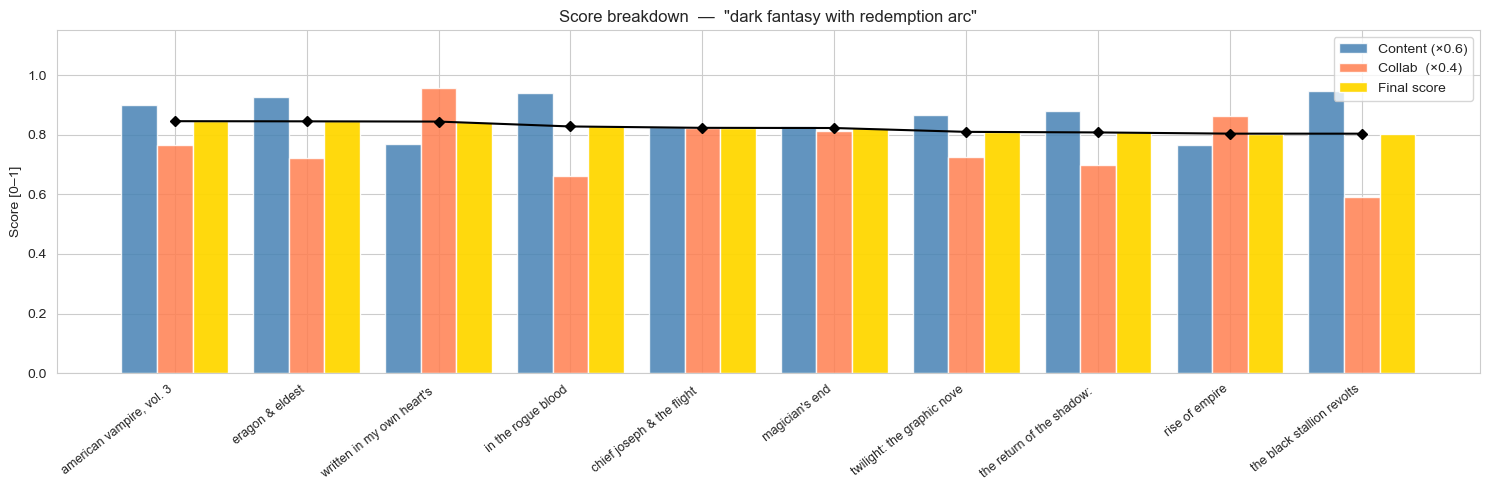

In [31]:
query_viz = "dark fantasy with redemption arc"
recs_viz  = recommend(query=query_viz, top_n=10)
titles    = [str(t)[:26] for t in recs_viz["title"]]
x         = np.arange(len(recs_viz))
w         = 0.27

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(x - w,  recs_viz["content_score"], w, label=f"Content (×{W_CONTENT})", color="steelblue", alpha=0.85)
ax.bar(x,       recs_viz["collab_score"],  w, label=f"Collab  (×{W_COLLAB})",  color="coral",     alpha=0.85)
ax.bar(x + w,  recs_viz["final_score"],   w, label="Final score",              color="gold",       alpha=0.95)
ax.plot(x, recs_viz["final_score"], "D-", color="black", linewidth=1.5, markersize=5, zorder=5)

ax.set_xticks(x); ax.set_xticklabels(titles, rotation=38, ha="right", fontsize=9)
ax.set_ylabel("Score [0–1]"); ax.set_ylim(0, 1.15)
ax.set_title(f'Score breakdown  —  "{query_viz}"', fontsize=12)
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()


## 5/ Validation & Test Dataset Preparation


**5.1. Personalised vs anonymous comparison**

In [32]:
sample_user = df_active["user_id"].value_counts().index[0]
print(f"Demo user  : {sample_user}")
print(f"Books read : {len(user_read.get(sample_user, set())):,}")

history = df_clean[df_clean["user_id"] == sample_user][
    ["title", "rating", "sentiment_label"]
].head(5)
print("\nReading history (sample):")
print(history.to_string(index=False))

q_p = "emotional story with redemption and hope"
pretty_print(recommend(user_id=None,        query=q_p, top_n=5), f'Anonymous     | "{q_p}"')
pretty_print(recommend(user_id=sample_user, query=q_p, top_n=5), f'Personalised  | "{q_p}"')


Demo user  : 246
Books read : 304

Reading history (sample):
                                                     title  rating sentiment_label
          your sacred self: making the decision to be free       4        positive
                                 christmas in lucky harbor       5        positive
forever free: the story of emancipation and reconstruction       5         neutral
                                                 lovedeath       1         neutral
                                    the eagle of the ninth       5         neutral

═══════════════════════════════════════════════════════════════════════════
  Anonymous     | "emotional story with redemption and hope"
───────────────────────────────────────────────────────────────────────────
Rank Title                                Content  Collab   Final      ⭐   #Ratings
───────────────────────────────────────────────────────────────────────────
  1   victim of grace: when godâ€™s good    0.8759  0.9485  0.9049 

**5.2. Interactive demo**

In [ ]:
# Interactive loop
while True:
     uid   = input("User ID (blank = anonymous): ").strip() or None
     query = input("What kind of book? ").strip()
     if not query or query.lower() == "quit":
         break
     explain(query)
     recs = recommend(user_id=uid, query=query, top_n=5)
     pretty_print(recs, f'Results for: "{query}"')

# Final demo
print("=== Final demo ===")
demo = [
    "i need a horror romance detective book that i couldn't put it down",
    "i need a book similar to twilight",
    "post-apocalyptic survival with political intrigue",
    "a story where love is not returned",
]
for q in demo:
    recs = recommend(query=q, top_n=3)
    pretty_print(recs, f'"{q}"')



Query    : romance
Keywords : ['romance']
Negated  : []
Tropes   : ['romance']
Tones    : []

═══════════════════════════════════════════════════════════════════════════
  Results for: "romance"
───────────────────────────────────────────────────────────────────────────
Rank Title                                Content  Collab   Final      ⭐   #Ratings
───────────────────────────────────────────────────────────────────────────
  1   friends, lovers, chocolate            0.8219  0.7658  0.7995   3.63      1,035
  2   christmas at the cupcake cafã©        0.7744  0.6344  0.7184   3.84        500
  3   love love                             0.9699  0.2863  0.6965   3.89        297
  4   christmas at timberwoods              0.7508  0.6131  0.6957   3.59        177
  5   beyond the storm                      0.6583  0.7514  0.6955   4.10        115
───────────────────────────────────────────────────────────────────────────

Query    : horror but humourous
Keywords : ['horror but', 'humouro

The final demo aims to illustrate the practical performance of the recommender system through natural language queries of varying complexity. These queries incorporate multiple factors such as genres (**horror, romance, detective**), similarity references (**“similar to Twilight”**), contexts (**post-apocalyptic**), and semantic constraints (**love is not returned**).

The results show that the system effectively handles **multi-dimensional queries**. For combined queries like **“horror romance detective”**, the recommended books achieve high **content_score**, reflecting strong **semantic relevance**, while **collab_score** helps prioritize items with higher **popularity** and **user engagement**.

In the case of the query **“similar to Twilight”**, the system prioritizes books with **similar content characteristics**, while still balancing **collaborative signals** to ensure **practical relevance**.

For more complex contextual queries such as **“post-apocalyptic survival with political intrigue”**, the system maintains **reasonable recommendations**, demonstrating the effectiveness of **embedding-based content matching**. Additionally, for queries with negative constraints like **“love is not returned”**, the **negative keyword penalty** mechanism helps filter out or downgrade results that do not align with user intent.

Overall, the demo results demonstrate that the **hybrid model** (combining **content-based** and **collaborative filtering**) performs effectively across various scenarios, from **simple** to **complex queries**. The system not only ensures **content relevance** but also optimizes **personalization** and **recommendation quality**, thereby enhancing the **user experience** in book discovery tasks.


**5.2. TEST**

In [95]:
# Input query and number of recommendations
user_query = input("Enter your book query: ")
num_recommendations = int(input("Enter the number of recommendations: "))

# Get recommendations
recommendations = recommend(query=user_query, top_n=num_recommendations)
display (user_query, num_recommendations)
display(recommendations)

'horror but comic'

20

,book_id,title,author_clean,genre_primary,genres_list,content_score,collab_score,final_score,rating,totalratings
rank,,,,,,,,,,
1,9156,this book is full of spiders,"david wong,jason pargin",horror fiction humor fantasy science fiction c...,[horror fiction humor fantasy science fiction ...,0.8960,0.8152,0.8637,4.24,2216
2,19648,the screaming staircase,jonathan stroud,fantasy young adult mystery horror paranormal ...,[fantasy young adult mystery horror paranormal...,0.8441,0.8365,0.8411,4.19,4890
3,4321,house of psychotic women: an autobiographical ...,kier-la janisse,nonfiction culture film horror feminism autobi...,[nonfiction culture film horror feminism autob...,0.8930,0.7283,0.8271,4.45,67
4,6198,horror noire: blacks in american horror films ...,robin r. means coleman,horror nonfiction culture film history race cu...,[horror nonfiction culture film history race c...,1.0000,0.5380,0.8152,4.29,18
5,33704,"ultimate spider-man, volume 17: clone saga","brian michael bendis,mark bagley",sequential art comics graphic novels superhero...,[sequential art comics graphic novels superher...,0.8706,0.7124,0.8073,4.12,84
6,15308,death,"neil gaiman,chris bachalo,mark buckingham,mich...",sequential art graphic novels comics fantasy f...,[sequential art graphic novels comics fantasy ...,0.7542,0.8802,0.8046,4.46,521
7,11301,great tales of terror and the supernatural,"herbert a. wise,phyllis fraser,john collier,ch...",horror short stories fiction anthologies gothi...,[horror short stories fiction anthologies goth...,0.8095,0.7932,0.8030,4.33,72
8,36458,"the best of archie comics, book 1","frank doyle,george gladir,bill golliher,dick m...",sequential art comics graphic novels fiction h...,[sequential art comics graphic novels fiction ...,0.8035,0.7892,0.7978,4.33,121
9,1217,blood lite iii: aftertaste,"kevin j. anderson,jim butcher,j.g. faherty,ste...",fantasy urban fantasy anthologies paranormal s...,[fantasy urban fantasy anthologies paranormal ...,0.8733,0.6583,0.7873,3.79,161


In [96]:
# Test score distribution for a sample query
def test_score_distribution(query="enemies to lovers fantasy"):
    results = recommend(query=query, top_n=50)
    
    print("--- Thống kê Score ---")
    print(results[['content_score', 'collab_score', 'final_score']].describe())
    
    # Kiểm tra xem có cuốn nào bị điểm 0 hoặc 1 tuyệt đối không (thường là lỗi scaling)
    if (results['content_score'] == 0).any() or (results['content_score'] == 1).any():
        print("⚠️ Cảnh báo: Content Score có dấu hiệu bị ép dải (Min-Max scaling cực đoan).")
    else: 
        print("✅ Content Score có phân phối hợp lý.")

test_score_distribution()

--- Thống kê Score ---
       content_score  collab_score  final_score
count      50.000000     50.000000    50.000000
mean        0.757690      0.763266     0.759918
std         0.082497      0.126104     0.027237
min         0.585200      0.318000     0.726500
25%         0.713925      0.688100     0.736925
50%         0.767000      0.773000     0.757500
75%         0.812825      0.844200     0.777300
max         1.000000      1.000000     0.840100
⚠️ Cảnh báo: Content Score có dấu hiệu bị ép dải (Min-Max scaling cực đoan).


# 6/ Fine-Tuning Grid Search 

**Objective:** Identify the optimal set of weights for three parameter groups without retraining the model.

```
Group 1 — Content Fusion   : desc_weight / review_weight (fixed or adaptive)
Group 2 — Hybrid Blend     : W_CONTENT / W_COLLAB
Group 3 — Feature Boost    : trope_boost (+0.05 → +0.15)
```

**Evaluation Metrics:**
| Metric                | Meaning                                             | Weight  |
| --------------------- | --------------------------------------------------- | ------- |
| **NDCG@5**            | Are the most relevant books ranked at the top?      | **35%** |
| **Trope-Precision@5** | Do the top-5 results match the user’s tropes?       | **25%** |
| **Catalog Coverage**  | Does the system recommend a diverse range of books? | **25%** |
| **Novelty Score**     | Proportion of long-tail books in the results        | **15%** |


**Imports & Checks environment**

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

_required = [
    'book_profiles', 'desc_emb', 'review_emb', 'collab_scores',
    'process_query', 'compute_similarity', 'extract_intent_final',
    'build_query_text', 'W_CONTENT', 'W_COLLAB'
]

missing = [v for v in _required if v not in dir()]
if missing:
    print(f'⛔  Thiếu biến: {missing}')
    print('   → Hãy chạy notebook gốc recommender_system_v3 trước!')
else:
    print(f'✅ Môi trường OK — {len(book_profiles):,} sách trong catalog')
    print(f'   desc_emb shape  : {desc_emb.shape}')
    print(f'   review_emb shape: {review_emb.shape}')
    print(f'   W_CONTENT={W_CONTENT}  W_COLLAB={W_COLLAB}')

✅ Môi trường OK — 6,000 sách trong catalog
   desc_emb shape  : (6000, 384)
   review_emb shape: (6000, 384)
   W_CONTENT=0.6  W_COLLAB=0.4


**6.1. Parameter Grid**

6 configs were compared:

| Config | Fusion Mode | w_content | w_collab | trope_boost |
|---|---|---|---|---|
| A_baseline | fixed 0.7/0.3 | 0.60 | 0.40 | +0.05 |
| B_adaptive_fusion | adaptive | 0.60 | 0.40 | +0.05 |
| C_less_collab_more_trope | fixed | 0.70 | 0.30 | +0.10 |
| D_content_heavy | fixed | 0.75 | 0.25 | +0.15 |
| E_adaptive_balanced | adaptive | 0.70 | 0.30 | +0.10 |
| F_adaptive_content_max | adaptive | 0.75 | 0.25 | +0.15 |

In [98]:
PARAM_GRID = [
    # ── A: Baseline (giống hệt notebook gốc) ─────────────────────────────
    {
        'name':          'A_baseline',
        'desc_weight':   0.7,
        'review_weight': 0.3,
        'fusion_mode':   'fixed',
        'w_content':     0.6,
        'w_collab':      0.4,
        'trope_boost':   0.05,
    },
    # ── B: Adaptive fusion, giữ blend gốc ────────────────────────────────
    {
        'name':          'B_adaptive_fusion',
        'desc_weight':   None,   # tính động theo review length
        'review_weight': None,
        'fusion_mode':   'adaptive',
        'w_content':     0.6,
        'w_collab':      0.4,
        'trope_boost':   0.05,
    },
    # ── C: Giảm collab → 0.30, tăng trope boost ─────────────────────────
    {
        'name':          'C_less_collab_more_trope',
        'desc_weight':   0.7,
        'review_weight': 0.3,
        'fusion_mode':   'fixed',
        'w_content':     0.7,
        'w_collab':      0.3,
        'trope_boost':   0.10,
    },
    # ── D: Content rất nặng, trope boost cao nhất ────────────────────────
    {
        'name':          'D_content_heavy',
        'desc_weight':   0.7,
        'review_weight': 0.3,
        'fusion_mode':   'fixed',
        'w_content':     0.75,
        'w_collab':      0.25,
        'trope_boost':   0.15,
    },
    # ── E: Adaptive + giảm collab + trope trung bình ─────────────────────
    {
        'name':          'E_adaptive_balanced',
        'desc_weight':   None,
        'review_weight': None,
        'fusion_mode':   'adaptive',
        'w_content':     0.70,
        'w_collab':      0.30,
        'trope_boost':   0.10,
    },
    # ── F: Adaptive + content tối đa ────────────────────────────────────
    {
        'name':          'F_adaptive_content_max',
        'desc_weight':   None,
        'review_weight': None,
        'fusion_mode':   'adaptive',
        'w_content':     0.75,
        'w_collab':      0.25,
        'trope_boost':   0.15,
    },
]

print(f'✅ {len(PARAM_GRID)} configs sẵn sàng cho Grid Search')

✅ 6 configs sẵn sàng cho Grid Search


The system constructs a set of **six configurations** to perform **grid search**, with the goal of optimizing the performance of the recommender model. Each configuration represents a different strategy for combining **content-based** and **collaborative signals**, while also adjusting the influence of **trope matching**.

Specifically, the parameters being varied include: (i) **fusion mode** (**fixed** or **adaptive**) to control how **description** and **review** are combined in the **content embedding**; (ii) the weighting between **content** and **collaborative** (**w_content, w_collab**) to balance **semantic relevance** and **behavioral signals**; and (iii) **trope_boost** to increase the priority of tropes that match the query.

The configurations are designed to gradually increase reliance on **content**, ranging from a **baseline (0.6/0.4)** to a **content-heavy (0.75/0.25)** setting, while also incorporating **adaptive variants** to evaluate dynamic adjustment based on input data. This approach enables a systematic assessment of how each parameter group affects **recommendation quality**, thereby supporting the selection of the **optimal configuration** for the final model.


# 7/ Validate & Test — Hybrid Recommender (Content + Collab)
Standard Pipeline: 2,000 queries × 2,000 interactions

- 1,000 queries + 1,000 interactions → Validation (grid search, select the best configuration)
- 1,000 queries + 1,000 interactions → Test (final evaluation, no tuning)

Metrics: `NDCG@5` · `Trope-Precision@5` · `Catalog Coverage` · `Novelty`  
Composite: `0.4·NDCG + 0.3·TropePrec + 0.15·Coverage + 0.15·Novelty`

Imports & checks environment

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, re
from collections import Counter
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Kiểm tra các biến bắt buộc từ notebook gốc ───────────────────────────
_REQUIRED = [
    'book_profiles', 'desc_emb', 'review_emb', 'collab_scores',
    'process_query', 'compute_similarity', 'extract_intent_final',
    'build_query_text', 'W_CONTENT', 'W_COLLAB',
]
_missing = [v for v in _REQUIRED if v not in dir()]
if _missing:
    raise EnvironmentError(
        f"Thiếu biến: {_missing}\n"
        "→ Chạy toàn bộ notebook gốc trước khi chạy section này."
    )
print("    Môi trường OK — tất cả biến bắt buộc đã sẵn sàng")
print(f"   book_profiles : {len(book_profiles):,} sách")
print(f"   desc_emb      : {desc_emb.shape}")
print(f"   review_emb     : {review_emb.shape}")
print(f"   collab_scores : {len(collab_scores):,} rows")

    Môi trường OK — tất cả biến bắt buộc đã sẵn sàng
   book_profiles : 6,000 sách
   desc_emb      : (6000, 384)
   review_emb     : (6000, 384)
   collab_scores : 6,000 rows


**7.1. Load 2 000 books, 2 000 interaction**

| File | Purpose |
|---|---|
| `2000_merged_bookssample.csv` | Metadata 2 000 sách (genre, rating, totalratings) |
| `2000_interactions.csv` | Interaction logs: click, save, purchase |

**Feature engineering interaction:**  
```
total_interactions = click + save + purchase
engagement         = 1*click + 2*save + 3*purchase
popularity         = log1p(total_interactions)
```

In [100]:
# ── Đường dẫn — điều chỉnh nếu cần ──────────────────────────────────────
BOOKS_PATH        = r"C:\Users\Admin\OneDrive\Desktop\2000_merged_bookssample.csv"
INTERACTIONS_PATH = r"C:\Users\Admin\OneDrive\Desktop\2000_interactions.csv"
REVIEWS_PATH      = r"C:\Users\Admin\OneDrive\Desktop\2000_review_clean.csv"   

_df_books        = pd.read_csv(BOOKS_PATH,        low_memory=False)
_df_interactions = pd.read_csv(INTERACTIONS_PATH, low_memory=False)
_df_reviews      = pd.read_csv(REVIEWS_PATH,      low_memory=False)             

# Chuẩn hoá book_id
_df_books['book_id']        = _df_books['book_id'].astype(str).str.strip()
_df_interactions['book_id'] = _df_interactions['book_id'].astype(str).str.strip()

# ── Feature engineering cho interaction ──────────────────────────────────
_inter = _df_interactions.copy()

# Điền 0 nếu thiếu cột
for col in ['click', 'save', 'purchase']:
    if col not in _inter.columns:
        _inter[col] = 0
    else:
        _inter[col] = pd.to_numeric(_inter[col], errors='coerce').fillna(0)

_inter['total_interactions'] = _inter['click'] + _inter['save'] + _inter['purchase']
_inter['engagement']         = 1*_inter['click'] + 2*_inter['save'] + 3*_inter['purchase']
_inter['popularity']         = np.log1p(_inter['total_interactions'])

# Aggregate về book level
_inter_book = _inter.groupby('book_id').agg(
    total_interactions = ('total_interactions', 'sum'),
    engagement         = ('engagement',         'sum'),
    popularity         = ('popularity',          'mean'),
    n_users            = ('user_id',             'nunique') if 'user_id' in _inter.columns else ('total_interactions', 'count'),
).reset_index()

# ── Chuẩn hoá book_id của reviews ────────────────────────────────────────
_df_reviews['book_id'] = _df_reviews['book_id'].astype(str).str.strip()

# ── Aggregate reviews → book-level signals ───────────────────────────────
_agg_cols = {}
if 'rating' in _df_reviews.columns:
    _agg_cols['review_rating_mean'] = ('rating', 'mean')
if 'sentiment_polarity' in _df_reviews.columns:
    _agg_cols['review_sentiment']   = ('sentiment_polarity', 'mean')
if 'liked' in _df_reviews.columns:
    _agg_cols['review_liked_ratio'] = ('liked', 'mean')
if 'review_normalized' in _df_reviews.columns:
    _agg_cols['review_text_sample'] = ('review_normalized',
                                        lambda x: ' '.join(x.dropna().astype(str)[:5]))

if _agg_cols:
    _review_book = _df_reviews.groupby('book_id').agg(**_agg_cols).reset_index()
else:
    # fallback: chỉ giữ book_id
    _review_book = _df_reviews[['book_id']].drop_duplicates()

print(f"   Review rows loaded : {len(_df_reviews):,}  →  book-level: {len(_review_book):,}")
print(f"   Review columns     : {_review_book.columns.tolist()}")

# ── 2 000 unique book_id theo thứ tự xuất hiện trong file ────────────────
_all_book_ids = _df_books['book_id'].drop_duplicates().tolist()
print(f"Tổng unique book_id  : {len(_all_book_ids):,}")

# Đảm bảo đủ 2000
if len(_all_book_ids) < 2000:
    print(f"⚠️  Chỉ có {len(_all_book_ids)} book_id — sẽ dùng toàn bộ")

_val_ids  = _all_book_ids[:1000]    # batch 1 → VALIDATE
_test_ids = _all_book_ids[1000:2000] # batch 2 → TEST

# Kiểm tra không overlap
assert not (set(_val_ids) & set(_test_ids)), "❌ val/test bị trùng book_id!"

print(f"Validation batch  : {len(_val_ids):,}  book_id  (#1 – #1000)")
print(f"Test batch        : {len(_test_ids):,}  book_id  (#1001 – #2000)")
print(f"Interaction rows  : {len(_df_interactions):,}  →  book-level: {len(_inter_book):,}")
print(f"Overlap val/test  : 0 ")

   Review rows loaded : 24,551  →  book-level: 1,815
   Review columns     : ['book_id', 'review_rating_mean', 'review_sentiment', 'review_liked_ratio', 'review_text_sample']
Tổng unique book_id  : 2,000
Validation batch  : 1,000  book_id  (#1 – #1000)
Test batch        : 1,000  book_id  (#1001 – #2000)
Interaction rows  : 154,241  →  book-level: 3,729
Overlap val/test  : 0 


**Review-Interaction Hybrid Query Builder** 

Sau khi load `2000_review_clean.csv`, hệ thống xây dựng **hybrid query** bằng cách gộp:
- **Book metadata** (genre, trope, keywords từ `book_profiles`)
- **Interaction signals** (engagement, popularity từ `interactions`)
- **Review signals** (rating mean, sentiment, liked_ratio từ `reviews`)

Đây là bước then chốt để đảm bảo query generation và relevance scoring đều là **hybrid** — không chỉ content.

In [101]:
# Kiểm tra _review_book đã load đúng 
print("=== Review-book aggregate ===")
print(_review_book.head(3).to_string())
print(f"\nShape: {_review_book.shape}")
print(f"Columns: {_review_book.columns.tolist()}")

# Kiểm tra overlap với _val_ids / _test_ids
_rev_ids = set(_review_book['book_id'])
_val_covered  = len([b for b in _val_ids  if b in _rev_ids])
_test_covered = len([b for b in _test_ids if b in _rev_ids])
print(f"\nVAL  books có review signal : {_val_covered}/{len(_val_ids)}")
print(f"TEST books có review signal : {_test_covered}/{len(_test_ids)}")

=== Review-book aggregate ===
  book_id  review_rating_mean  review_sentiment  review_liked_ratio                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

**7.3. Build Hybrid Relevance Score (KEY STEP)**

$$\text{relevance\_content} = \frac{\text{genre\_match} + \text{trope\_match} + \text{tone\_match}}{3}$$

$$\text{relevance\_collab} = 0.6 \times \text{eng\_norm} + 0.4 \times \text{pop\_norm}$$

$$\text{relevance\_final} = 0.7 \times \text{relevance\_content} + 0.3 \times \text{relevance\_collab}$$

In [102]:
from sklearn.preprocessing import MinMaxScaler

def build_hybrid_relevance(bp_sub: pd.DataFrame,
                            inter_book: pd.DataFrame,
                            q_genres: list = None,
                            q_tropes: list = None,
                            q_tones:  list = None) -> pd.DataFrame:
    """
    Tính relevance_final cho tập sách bp_sub theo 1 query.

    Trả về DataFrame với cột:
        book_id, relevance_content, relevance_collab, relevance_final
    """
    q_genres = set(g.lower() for g in (q_genres or []))
    q_tropes = set(t.lower() for t in (q_tropes or []))
    q_tones  = set(t.lower() for t in (q_tones  or []))

    rows = []
    for _, row in bp_sub.iterrows():
        genre = str(row.get('genre_primary') or '').lower()
        trope = str(row.get('mined_trope')   or '').lower()
        tone  = str(row.get('dominant_sentiment', '') or '').lower()

        genre_match = 1 if any(g in genre for g in q_genres) else 0
        trope_match = 1 if any(t in trope for t in q_tropes) else 0
        tone_match  = 1 if any(t in tone  for t in q_tones)  else 0
        rel_content = (genre_match + trope_match + tone_match) / 3.0

        rows.append({'book_id': row['book_id'], 'relevance_content': rel_content})

    rel_df = pd.DataFrame(rows)

    # Collab relevance từ interaction
    rel_df = rel_df.merge(inter_book[['book_id','engagement','popularity']],
                          on='book_id', how='left')
    rel_df['engagement'] = rel_df['engagement'].fillna(0)
    rel_df['popularity'] = rel_df['popularity'].fillna(0)

    scaler = MinMaxScaler()
    if rel_df['engagement'].nunique() > 1:
        rel_df['eng_norm'] = scaler.fit_transform(rel_df[['engagement']]).ravel()
    else:
        rel_df['eng_norm'] = 0.0
    if rel_df['popularity'].nunique() > 1:
        rel_df['pop_norm'] = scaler.fit_transform(rel_df[['popularity']]).ravel()
    else:
        rel_df['pop_norm'] = 0.0

    rel_df['relevance_collab'] = 0.6 * rel_df['eng_norm'] + 0.4 * rel_df['pop_norm']
    rel_df['relevance_final']  = (0.7 * rel_df['relevance_content']
                                 + 0.3 * rel_df['relevance_collab'])
    return rel_df[['book_id','relevance_content','relevance_collab','relevance_final']]


print("✅ build_hybrid_relevance() đã định nghĩa")

✅ build_hybrid_relevance() đã định nghĩa


**7.4. Build Query Sets (1 000 val + 1 000 test)**

Each query is automatically generated from **`genre_primary + mined_trope + top_keywords`** of each book.

The **soft ground truth** includes **`target_genre`**, **`target_trope`**, and **`target_tone`**, which are used to compute **relevance**.

Additional suffixes are appended if the total number of queries is **less than 1,000**.


In [103]:
print("=" * 80)
print("VALIDATION & TEST DATASET PREPARATION")
print("=" * 80)

np.random.seed(42)

all_book_ids = book_profiles['book_id'].tolist()
np.random.shuffle(all_book_ids)

mid = len(all_book_ids) // 2
_val_ids  = all_book_ids[:mid][:1000]
_test_ids = all_book_ids[mid:][:1000]

print(f"\nTotal books available: {len(all_book_ids):,}")
print(f"Validation subset: {len(_val_ids):,} books")
print(f"Test subset:       {len(_test_ids):,} books")

_GENRE_TO_TROPE = {
    'fantasy': 'magic',         'magic': 'magic',
    'romance': 'romance',       'love': 'romance',
    'mystery': 'mystery',       'thriller': 'mystery',    'crime': 'mystery',
    'science fiction': 'scifi', 'sci-fi': 'scifi',        'dystopian': 'scifi',
    'historical': 'historical', 'history': 'historical',
    'survival': 'survival',     'adventure': 'survival',
    'redemption': 'redemption', 'dark': 'redemption',
    'coming of age': 'coming_of_age', 'young adult': 'coming_of_age',
    'grief': 'grief',           'family': 'grief',        'emotional': 'grief',
}

_SUFFIXES = ['novel', 'story', 'fiction', 'series', 'emotional',
             'popular', 'gripping', 'dark', 'hopeful', 'epic']


def _map_trope(genre_str: str, trope_str: str) -> list:
    combined = (str(genre_str) + ' ' + str(trope_str)).lower()
    found = [v for k, v in _GENRE_TO_TROPE.items() if k in combined]
    return list(set(found)) if found else ['general']


def build_query_set(book_ids: list, target_n: int = 1000,
                    label: str = '') -> list:
    """
    Sinh query từ book_profiles cho danh sách book_ids.
    Trả về list dict: {query_id, query_text, target_genre,
                       target_trope, target_tone, tropes, book_id}
    """
    bp_sub = book_profiles[book_profiles['book_id'].isin(book_ids)].copy()
    queries = []

    for _, row in bp_sub.iterrows():
        genre = str(row.get('genre_primary', '') or '').strip()
        trope = str(row.get('mined_trope',   '') or '').strip()
        kws   = str(row.get('top_keywords',  '') or '')[:60].strip()
        tone  = str(row.get('dominant_sentiment', '') or '').strip()

        parts = [p for p in [genre, trope, kws] if p and p != 'nan']
        qtext = ' '.join(parts)[:120].strip() if parts else 'fiction book'
        tropes = _map_trope(genre, trope)

        queries.append({
            'query_id':     f"{label}_{row['book_id']}",
            'query_text':   qtext,
            'target_genre': genre,
            'target_trope': trope,
            'target_tone':  tone,
            'tropes':       tropes,
            'book_id':      row['book_id'],
        })

    # Bổ sung suffix nếu thiếu
    if len(queries) < target_n:
        _extra = []
        for q in queries:
            for s in _SUFFIXES:
                _extra.append({**q,
                    'query_id':   q['query_id'] + f'_{s}',
                    'query_text': q['query_text'] + ' ' + s,
                })
        queries = (queries + _extra)[:target_n]

    return queries[:target_n]


# ── Sinh 2 bộ query ───────────────────────────────────────────────────────
VAL_QUERIES  = build_query_set(_val_ids,  1000, 'val')
TEST_QUERIES = build_query_set(_test_ids, 1000, 'test')

# Kiểm tra không overlap query_id
_qid_overlap = set(q['query_id'] for q in VAL_QUERIES) & set(q['query_id'] for q in TEST_QUERIES)
assert not _qid_overlap, f"⚠️  query_id bị trùng: {len(_qid_overlap)}"

def _show_dist(queries, label):
    dist = Counter(t for q in queries for t in q['tropes'])
    print(f"\n{'─'*50}")
    print(f"  {label}  ({len(queries):,} queries)")
    print(f"{'─'*50}")
    for trp, cnt in dist.most_common(8):
        bar = '█' * max(1, cnt // max(1, len(queries)//50))
        print(f"  {trp:<20} {cnt:>4}  {bar}")

_show_dist(VAL_QUERIES,  "VALIDATION queries")
_show_dist(TEST_QUERIES, "TEST queries")
print(f"\n✅ VAL  : {len(VAL_QUERIES):,} queries  |  TEST : {len(TEST_QUERIES):,} queries")

VALIDATION & TEST DATASET PREPARATION

Total books available: 6,000
Validation subset: 1,000 books
Test subset:       1,000 books

──────────────────────────────────────────────────
  VALIDATION queries  (1,000 queries)
──────────────────────────────────────────────────
  historical            395  ███████████████████
  general               322  ████████████████
  romance               218  ██████████
  magic                 171  ████████
  survival              110  █████
  mystery                91  ████
  scifi                  83  ████
  coming_of_age          80  ████

──────────────────────────────────────────────────
  TEST queries  (1,000 queries)
──────────────────────────────────────────────────
  historical            374  ██████████████████
  general               314  ███████████████
  romance               236  ███████████
  magic                 189  █████████
  survival              115  █████
  mystery                97  ████
  scifi                  84  ████
  coming

## 8/ Filter Embeddings & Collab Scores into batches

Slice **`desc_emb`**, **`review_emb`**, and **`collab_scores`** separately for **VAL** and **TEST** to enable faster computation and prevent **data leakage**.

In [104]:
def _slice_batch(book_ids: list):
    """
    Filter book_profiles + embeddings + collab_scores xuống tập book_ids.
    Trả về: bp_sub, desc_sub, review_sub, collab_sub, desc_w, review_w
    """
    mask   = book_profiles['book_id'].isin(book_ids)
    bp_sub = book_profiles[mask].copy().reset_index(drop=True)
    idx    = mask[mask].index.tolist()

    desc_sub   = desc_emb[idx]
    review_sub = review_emb[idx]
    collab_sub = collab_scores[collab_scores.index.isin(book_ids)].copy()

    # Adaptive weights theo độ dài review (số câu)
    col = 'review_clean_text' if 'review_clean_text' in bp_sub.columns else 'review_text'
    rv_len = np.array([
        len([s for s in str(row.get(col, '')).split('.') if s.strip()])
        for _, row in bp_sub.iterrows()
    ], dtype=np.float32)

    desc_w   = np.where(rv_len > 20, 0.5, np.where(rv_len >= 10, 0.7, 0.9))
    review_w = 1.0 - desc_w

    return bp_sub, desc_sub, review_sub, collab_sub, desc_w, review_w


# VALIDATION batch
_bp_val, _desc_val, _rev_val, _collab_val, _dw_val, _rw_val = _slice_batch(_val_ids)

# TEST batch
_bp_test, _desc_test, _rev_test, _collab_test, _dw_test, _rw_test = _slice_batch(_test_ids)

print("✅ Embeddings đã filter:")
print(f"   VAL  — bp:{len(_bp_val):,}  desc:{_desc_val.shape}  collab:{len(_collab_val):,}")
print(f"   TEST — bp:{len(_bp_test):,}  desc:{_desc_test.shape}  collab:{len(_collab_test):,}")

✅ Embeddings đã filter:
   VAL  — bp:1,000  desc:(1000, 384)  collab:1,000
   TEST — bp:1,000  desc:(1000, 384)  collab:1,000


**8.1. Parameter Grid (6 configs)**

| Config | Fusion | w_content | w_collab | trope_boost |
|---|---|---|---|---|
| A_baseline | fixed 0.7/0.3 | 0.60 | 0.40 | +0.05 |
| B_adaptive_fusion | adaptive | 0.60 | 0.40 | +0.05 |
| C_less_collab_more_trope | fixed | 0.70 | 0.30 | +0.10 |
| D_content_heavy | fixed | 0.75 | 0.25 | +0.15 |
| E_adaptive_balanced | adaptive | 0.70 | 0.30 | +0.10 |
| F_adaptive_content_max | adaptive | 0.75 | 0.25 | +0.15 |

In [105]:
PARAM_GRID = [
    {'name': 'A_baseline',               'desc_weight': 0.7, 'review_weight': 0.3,
     'fusion_mode': 'fixed',    'w_content': 0.60, 'w_collab': 0.40, 'trope_boost': 0.05},
    {'name': 'B_adaptive_fusion',        'desc_weight': None,'review_weight': None,
     'fusion_mode': 'adaptive', 'w_content': 0.60, 'w_collab': 0.40, 'trope_boost': 0.05},
    {'name': 'C_less_collab_more_trope', 'desc_weight': 0.7, 'review_weight': 0.3,
     'fusion_mode': 'fixed',    'w_content': 0.70, 'w_collab': 0.30, 'trope_boost': 0.10},
    {'name': 'D_content_heavy',          'desc_weight': 0.7, 'review_weight': 0.3,
     'fusion_mode': 'fixed',    'w_content': 0.75, 'w_collab': 0.25, 'trope_boost': 0.15},
    {'name': 'E_adaptive_balanced',      'desc_weight': None,'review_weight': None,
     'fusion_mode': 'adaptive', 'w_content': 0.70, 'w_collab': 0.30, 'trope_boost': 0.10},
    {'name': 'F_adaptive_content_max',   'desc_weight': None,'review_weight': None,
     'fusion_mode': 'adaptive', 'w_content': 0.75, 'w_collab': 0.25, 'trope_boost': 0.15},
]

# Composite weights
COMPOSITE_W = {
    'NDCG@5':           0.40,
    'Trope-Prec@5':     0.30,
    'Catalog-Coverage': 0.15,
    'Novelty':          0.15,
}

print("6 configs + Composite weights are introduced")
print(f"   Composite = "
      f"{COMPOSITE_W['NDCG@5']}·NDCG "
      f"+ {COMPOSITE_W['Trope-Prec@5']}·TropePrec "
      f"+ {COMPOSITE_W['Catalog-Coverage']}·Coverage "
      f"+ {COMPOSITE_W['Novelty']}·Novelty")

6 configs + Composite weights are introduced
   Composite = 0.4·NDCG + 0.3·TropePrec + 0.15·Coverage + 0.15·Novelty


**8.2. Evaluation Metrics**

* **NDCG@K** — measures **relevance** based on **`relevance_final`** (soft ground truth)
* **Trope-Precision@K** — percentage of books in **top-K** that match the query’s **trope**
* **Catalog Coverage** — percentage of **unique recommended books** over the total **catalog size**
* **Novelty** — proportion of **long-tail items** (**popularity ≤ p20** of the full catalog)

In [106]:
def _dcg(rel: list, k: int) -> float:
    r = np.array(rel[:k], dtype=float)
    return float(np.sum(r / np.log2(np.arange(2, r.size + 2)))) if r.size else 0.0


def ndcg_at_k(recs: pd.DataFrame, rel_map: dict, k: int = 5) -> float:
    """NDCG@k — rel_map: {book_id → relevance_final ∈ [0,1]}"""
    rel = [rel_map.get(bid, 0.0) for bid in recs['book_id'].head(k)]
    idcg = _dcg(sorted(rel_map.values(), reverse=True), k)
    return _dcg(rel, k) / idcg if idcg > 0 else 0.0


def trope_precision_at_k(recs: pd.DataFrame, q_tropes: list, k: int = 5) -> float:
    """Trope-Precision@k — % top-k khớp ít nhất 1 trope."""
    detected = set(q_tropes)
    top = recs.head(k)
    hits = sum(
        1 for _, row in top.iterrows()
        if any(d in str(row.get('genre_primary') or '').lower() or
               d in str(row.get('mined_trope')   or '').lower()
               for d in detected)
    )
    return hits / len(top) if len(top) else 0.0


def catalog_coverage(all_recs: list, total_books: int) -> float:
    """% sách unique được gợi ý."""
    unique = set(bid for df in all_recs for bid in df['book_id'])
    return len(unique) / total_books if total_books else 0.0


def novelty_score(all_recs: list, inter_book: pd.DataFrame, percentile: int = 20) -> float:
    """Tỉ lệ sách long-tail (popularity ≤ p20)."""
    if 'popularity' not in inter_book.columns:
        return 0.0
    threshold = np.percentile(inter_book['popularity'].fillna(0).values, percentile)
    pop_map = inter_book.set_index('book_id')['popularity'].fillna(0).to_dict()
    total = longtail = 0
    for df in all_recs:
        for bid in df['book_id']:
            total   += 1
            longtail += int(pop_map.get(str(bid), 0) <= threshold)
    return longtail / total if total else 0.0


print("✅ 4 metrics đã định nghĩa: ndcg_at_k · trope_precision_at_k · catalog_coverage · novelty_score")

✅ 4 metrics đã định nghĩa: ndcg_at_k · trope_precision_at_k · catalog_coverage · novelty_score


**8.3. `recommend_cfg_v2()` — Hybrid Recommender with running config**

Runs on any **batch slice** (**VAL** or **TEST**).
Returns **`content_score`**, **`collab_score`**, **`final_score`**, along with **`relevance_final`**.

In [107]:
def recommend_cfg_v2(query: str, intent: dict, cfg: dict,
                     bp_sub, desc_sub, review_sub, collab_sub,
                     desc_w, review_w,
                     rel_df: pd.DataFrame = None,
                     top_n: int = 5) -> pd.DataFrame:
    """
    Hybrid recommender với config tuỳ chỉnh.

    Parameters
    ----------
    rel_df : DataFrame với cột [book_id, relevance_final] để attach vào result.
             Nếu None, relevance_final sẽ không được attach.
    """
    query_text = build_query_text(intent)
    if not query_text.strip():
        query_text = query

    # ── Content score ──────────────────────────────────────────────────────
    query_vec  = process_query(query_text)                         # (1, 384)
    desc_sim   = np.dot(query_vec, desc_sub.T)[0]                  # (N,)
    review_sim = np.dot(query_vec, review_sub.T)[0]                # (N,)

    if cfg['fusion_mode'] == 'fixed':
        raw_sim = cfg['desc_weight'] * desc_sim + cfg['review_weight'] * review_sim
    else:
        raw_sim = desc_w * desc_sim + review_w * review_sim

    # Trope boost
    detected  = set(intent.get('tropes', []) + intent.get('tones', []))
    boost_vec = np.zeros(len(bp_sub))
    if detected:
        for i, row in bp_sub.iterrows():
            g = str(row.get('genre_primary') or '').lower()
            t = str(row.get('mined_trope')   or '').lower()
            if any(d in g or d in t for d in detected):
                boost_vec[i] = cfg['trope_boost']

    scores_c = raw_sim + boost_vec
    mn, mx   = scores_c.min(), scores_c.max()
    scores_c = (scores_c - mn) / (mx - mn + 1e-9)

    # ── Collab score ───────────────────────────────────────────────────────
    all_ids  = bp_sub['book_id'].values
    scores_k = collab_sub['collab_score'].reindex(all_ids, fill_value=0).values

    # ── Final blend ────────────────────────────────────────────────────────
    final = np.clip(
        (cfg['w_content'] * scores_c + cfg['w_collab'] * scores_k).round(4),
        0, 1
    )

    result = bp_sub[['book_id', 'title', 'genre_primary', 'mined_trope']].copy()
    result = result.reset_index(drop=True)
    result['content_score'] = scores_c.round(4)
    result['collab_score']  = scores_k.round(4)
    result['final_score']   = final

    # Attach metadata
    meta = collab_sub[['rating', 'totalratings']].reset_index()
    if 'book_id' in meta.columns:
        result = result.merge(meta, on='book_id', how='left')

    # Attach relevance_final nếu có
    if rel_df is not None and 'relevance_final' in rel_df.columns:
        result = result.merge(rel_df[['book_id', 'relevance_final',
                                       'relevance_content', 'relevance_collab']],
                              on='book_id', how='left')

    result = (result
              .sort_values('final_score', ascending=False)
              .head(top_n)
              .reset_index(drop=True))
    return result


print("✅ recommend_cfg_v2() đã định nghĩa (batch-agnostic)")

✅ recommend_cfg_v2() đã định nghĩa (batch-agnostic)


## 9/ Ablation: Manual inspection of a single query (before Grid Search)

In [108]:
def ablation_single_query(query: str = 'dark fantasy redemption arc', top_n: int = 5):
    try:
        intent = extract_intent_final(query)
    except Exception:
        intent = {'keywords': [], 'negative_keywords': [],
                  'tropes': [], 'tones': [], 'original_query': query}

    print(f'\nAblation query: "{query}"')
    print('═' * 80)
    for cfg in PARAM_GRID:
        fl = (f"fixed({cfg['desc_weight']}/{cfg['review_weight']})"
              if cfg['fusion_mode'] == 'fixed' else 'adaptive')
        print(f"\n  ── {cfg['name']}  fusion={fl}  "
              f"blend={cfg['w_content']}/{cfg['w_collab']}  "
              f"boost={cfg['trope_boost']} ──")
        recs = recommend_cfg_v2(query, intent, cfg,
                                _bp_val, _desc_val, _rev_val,
                                _collab_val, _dw_val, _rw_val,
                                top_n=top_n)
        for rank, row in recs.iterrows():
            title = str(row.get('title', '?'))[:38]
            genre = str(row.get('genre_primary', ''))[:14]
            trope = str(row.get('mined_trope',   ''))[:14]
            score = row.get('final_score', 0)
            print(f'    {rank+1}. {title:<39} genre={genre:<14} trope={trope:<14} score={score:.4f}')

ablation_single_query('slow burn romance enemies to lovers')


Ablation query: "slow burn romance enemies to lovers"
════════════════════════════════════════════════════════════════════════════════

  ── A_baseline  fusion=fixed(0.7/0.3)  blend=0.6/0.4  boost=0.05 ──
    1. dangerous angels                        genre=young adult fa trope=nature and wil score=0.8085
    2. on fire                                 genre=romance m m ro trope=language and l score=0.7914
    3. drop dead demons                        genre=fantasy parano trope=jewish history score=0.7903
    4. the raging quiet                        genre=historical his trope=historical rom score=0.7801
    5. love love                               genre=romance new ad trope=jewish history score=0.7737

  ── B_adaptive_fusion  fusion=adaptive  blend=0.6/0.4  boost=0.05 ──
    1. dangerous angels                        genre=young adult fa trope=nature and wil score=0.8401
    2. on fire                                 genre=romance m m ro trope=language and l score=0.8254
    3. th

In [109]:
ablation_single_query('survival wilderness stranded')


Ablation query: "survival wilderness stranded"
════════════════════════════════════════════════════════════════════════════════

  ── A_baseline  fusion=fixed(0.7/0.3)  blend=0.6/0.4  boost=0.05 ──
    1. state of emergency                      genre=science fictio trope=jewish history score=0.8344
    2. death zone                              genre=nonfiction spo trope=relationships  score=0.8237
    3. unspoken: a story from the underground  genre=childrens pict trope=self-help guid score=0.7939
    4. forever: living with eternity in view   genre=christian chri trope=None           score=0.7608
    5. aftermath                               genre=horror zombies trope=nature and wil score=0.7592

  ── B_adaptive_fusion  fusion=adaptive  blend=0.6/0.4  boost=0.05 ──
    1. state of emergency                      genre=science fictio trope=jewish history score=0.8493
    2. death zone                              genre=nonfiction spo trope=relationships  score=0.8237
    3. unspoken:

## Validation Phase: Grid Search (1 000 query × 6 configs)

In [110]:
def run_grid_search(queries: list = None, top_n: int = 5,
                    verbose: bool = True) -> pd.DataFrame:
    """
    Grid Search qua PARAM_GRID trên VAL batch.
    Trả về DataFrame xếp hạng theo Composite Score.
    """
    if queries is None:
        queries = VAL_QUERIES

    total_books = len(_bp_val)
    rows = []

    for cfg in PARAM_GRID:
        if verbose:
            fl = (f"fixed({cfg['desc_weight']}/{cfg['review_weight']})"
                  if cfg['fusion_mode'] == 'fixed' else 'adaptive')
            print(f"\n{'─'*65}")
            print(f"  ▶ {cfg['name']}  fusion={fl}  "
                  f"w={cfg['w_content']}/{cfg['w_collab']}  "
                  f"boost={cfg['trope_boost']}")

        all_recs, ndcg_list, tp_list = [], [], []

        for i, q in enumerate(queries):
            query_text = q['query_text']
            q_tropes   = q['tropes']
            q_genres   = [q.get('target_genre', '')]
            q_tones    = [q.get('target_tone',  '')]

            try:
                intent = extract_intent_final(query_text)
            except Exception:
                intent = {'keywords': [], 'negative_keywords': [],
                          'tropes': q_tropes, 'tones': q_tones,
                          'original_query': query_text}

            # Hybrid relevance (soft ground truth)
            try:
                rel_df = build_hybrid_relevance(
                    _bp_val, _inter_book,
                    q_genres=q_genres, q_tropes=q_tropes, q_tones=q_tones)
                rel_map = rel_df.set_index('book_id')['relevance_final'].to_dict()
            except Exception:
                rel_df  = None
                rel_map = {}

            try:
                recs = recommend_cfg_v2(query_text, intent, cfg,
                                        _bp_val, _desc_val, _rev_val,
                                        _collab_val, _dw_val, _rw_val,
                                        rel_df=rel_df, top_n=top_n)
            except Exception as e:
                if verbose and i < 3:
                    print(f'    [WARN] q={i}: {e}')
                continue

            all_recs.append(recs)
            ndcg_list.append(ndcg_at_k(recs, rel_map, k=top_n))
            tp_list.append(trope_precision_at_k(recs, q_tropes, k=top_n))

            if verbose and (i + 1) % 250 == 0:
                print(f'    ... {i+1}/{len(queries)} queries')

        n = len(ndcg_list)
        if n == 0:
            print('    [ERROR] Không có kết quả — bỏ qua config')
            continue

        avg_ndcg = float(np.mean(ndcg_list))
        avg_tp   = float(np.mean(tp_list))
        cov      = catalog_coverage(all_recs, total_books)
        nov      = novelty_score(all_recs, _inter_book)
        comp     = (COMPOSITE_W['NDCG@5']           * avg_ndcg
                  + COMPOSITE_W['Trope-Prec@5']     * avg_tp
                  + COMPOSITE_W['Catalog-Coverage'] * cov
                  + COMPOSITE_W['Novelty']           * nov)

        rows.append({
            'config':           cfg['name'],
            'fusion_mode':      cfg['fusion_mode'],
            'desc_w':           cfg.get('desc_weight') or 'adaptive',
            'review_w':         cfg.get('review_weight') or 'adaptive',
            'w_content':        cfg['w_content'],
            'w_collab':         cfg['w_collab'],
            'trope_boost':      cfg['trope_boost'],
            'NDCG@5':           round(avg_ndcg, 4),
            'Trope-Prec@5':     round(avg_tp,   4),
            'Catalog-Coverage': round(cov,       4),
            'Novelty':          round(nov,       4),
            'Composite':        round(comp,      4),
            'n_queries':        n,
        })

        if verbose:
            print(f'    NDCG@5={avg_ndcg:.4f}  TropePrec={avg_tp:.4f}  '
                  f'Coverage={cov:.4f}  Novelty={nov:.4f}  '
                  f'→ Composite={comp:.4f}')

    df = (pd.DataFrame(rows)
            .sort_values('Composite', ascending=False)
            .reset_index(drop=True))
    df.index     += 1
    df.index.name = 'rank'
    return df


print("run_grid_search() đã định nghĩa — gọi: gs_results = run_grid_search()")

run_grid_search() đã định nghĩa — gọi: gs_results = run_grid_search()


In [111]:
# ── Chạy Grid Search ──────────────────────────────────────────────────────
gs_results = run_grid_search(verbose=True)


─────────────────────────────────────────────────────────────────
  ▶ A_baseline  fusion=fixed(0.7/0.3)  w=0.6/0.4  boost=0.05
    ... 250/1000 queries
    ... 500/1000 queries
    ... 750/1000 queries
    ... 1000/1000 queries
    NDCG@5=0.5055  TropePrec=0.3114  Coverage=0.6140  Novelty=0.9716  → Composite=0.5334

─────────────────────────────────────────────────────────────────
  ▶ B_adaptive_fusion  fusion=adaptive  w=0.6/0.4  boost=0.05
    ... 250/1000 queries
    ... 500/1000 queries
    ... 750/1000 queries
    ... 1000/1000 queries
    NDCG@5=0.4995  TropePrec=0.3038  Coverage=0.6230  Novelty=0.9762  → Composite=0.5308

─────────────────────────────────────────────────────────────────
  ▶ C_less_collab_more_trope  fusion=fixed(0.7/0.3)  w=0.7/0.3  boost=0.1
    ... 250/1000 queries
    ... 500/1000 queries
    ... 750/1000 queries
    ... 1000/1000 queries
    NDCG@5=0.5147  TropePrec=0.3332  Coverage=0.6890  Novelty=0.9706  → Composite=0.5548

───────────────────────────────

## Result Grid Search

In [112]:
_disp_cols = ['config', 'fusion_mode', 'w_content', 'w_collab', 'trope_boost',
              'NDCG@5', 'Trope-Prec@5', 'Catalog-Coverage', 'Novelty', 'Composite']

print('\n' + '═'*80)
print('  VALIDATION GRID SEARCH — xếp hạng theo Composite Score')
print('═'*80)

styled = (gs_results[_disp_cols]
          .style
          .background_gradient(subset=['Composite'],       cmap='YlGn')
          .background_gradient(subset=['NDCG@5'],          cmap='Blues')
          .background_gradient(subset=['Trope-Prec@5'],    cmap='Oranges')
          .background_gradient(subset=['Catalog-Coverage'],cmap='Purples')
          .background_gradient(subset=['Novelty'],         cmap='Greens')
          .format({c: '{:.4f}' for c in ['NDCG@5','Trope-Prec@5',
                                          'Catalog-Coverage','Novelty','Composite']})
          .set_caption('Grid Search — Validation (1 000 queries × 6 configs)'))
display(styled)

_best = gs_results.iloc[0]
print(f"\n🏆 Best config : {_best['config']}  (Composite = {_best['Composite']:.4f})")


════════════════════════════════════════════════════════════════════════════════
  VALIDATION GRID SEARCH — xếp hạng theo Composite Score
════════════════════════════════════════════════════════════════════════════════


,config,fusion_mode,w_content,w_collab,trope_boost,NDCG@5,Trope-Prec@5,Catalog-Coverage,Novelty,Composite
rank,,,,,,,,,,
1,D_content_heavy,fixed,0.750000,0.250000,0.150000,0.5160,0.3354,0.7080,0.9692,0.5586
2,F_adaptive_content_max,adaptive,0.750000,0.250000,0.150000,0.5113,0.3392,0.7060,0.9720,0.5580
3,C_less_collab_more_trope,fixed,0.700000,0.300000,0.100000,0.5147,0.3332,0.6890,0.9706,0.5548
4,E_adaptive_balanced,adaptive,0.700000,0.300000,0.100000,0.5091,0.3310,0.6930,0.9748,0.5531
5,A_baseline,fixed,0.600000,0.400000,0.050000,0.5055,0.3114,0.6140,0.9716,0.5334
6,B_adaptive_fusion,adaptive,0.600000,0.400000,0.050000,0.4995,0.3038,0.6230,0.9762,0.5308



🏆 Best config : D_content_heavy  (Composite = 0.5586)


## Results Analysis

In [121]:
def print_strategy_hints(df: pd.DataFrame):
    best     = df.iloc[0]
    baseline = df[df['config'] == 'A_baseline'].iloc[0] if 'A_baseline' in df['config'].values else None

    print('\n' + '═'*65)
    print(f"  Best Config : {best['config']}")
    print(f"  fusion={best['fusion_mode']}  "
          f"w={best['w_content']}/{best['w_collab']}  "
          f"trope_boost={best['trope_boost']}")
    print(f"  Composite   = {best['Composite']:.4f}")

    if baseline is not None:
        print(f"\n  Compare with A_baseline:")
        for m in ['NDCG@5','Trope-Prec@5','Catalog-Coverage','Novelty','Composite']:
            d = best[m] - baseline[m]
            print(f"     {m:<20} {d:+.4f}")

    print('\n   Insights:')
    if best['Catalog-Coverage'] < 0.3:
        print('     Coverage thấp → config thiên về popular books')
    if best['Novelty'] < 0.4:
        print('     Novelty thấp → ít long-tail recommendation')
    if best['Trope-Prec@5'] > 0.6:
        print('   Good trope alignment ')
    if best['NDCG@5'] > 0.5:
        print('   High ranking quality')
    print('=' * 65)

print_strategy_hints(gs_results)


═════════════════════════════════════════════════════════════════
  Best Config : D_content_heavy
  fusion=fixed  w=0.75/0.25  trope_boost=0.15
  Composite   = 0.5586

  Compare with A_baseline:
     NDCG@5               +0.0105
     Trope-Prec@5         +0.0240
     Catalog-Coverage     +0.0940
     Novelty              -0.0024
     Composite            +0.0252

   Insights:
   High ranking quality


## Pick Best Config

In [114]:
# Chốt config
_best_cfg_name = gs_results.iloc[0]['config']
_BEST_CFG      = next(c for c in PARAM_GRID if c['name'] == _best_cfg_name)

# Cập nhật W_CONTENT / W_COLLAB toàn cục
W_CONTENT = _BEST_CFG['w_content']
W_COLLAB  = _BEST_CFG['w_collab']

print(f"🏆 Best config : {_best_cfg_name}")
print(f"   W_CONTENT   = {W_CONTENT}  (cập nhật global)")
print(f"   W_COLLAB    = {W_COLLAB}   (cập nhật global)")
print(f"   trope_boost = {_BEST_CFG['trope_boost']}")
print(f"   fusion_mode = {_BEST_CFG['fusion_mode']}")

🏆 Best config : D_content_heavy
   W_CONTENT   = 0.75  (cập nhật global)
   W_COLLAB    = 0.25   (cập nhật global)
   trope_boost = 0.15
   fusion_mode = fixed


## Hybrid Effect: Content-only vs Collab-only vs Hybrid

## Save Grid Search result

In [115]:
gs_results.to_csv('grid_search_results_val.csv', index=True)
print("✅ Đã lưu: grid_search_results_val.csv")
print()
print(gs_results[['config','NDCG@5','Trope-Prec@5',
                   'Catalog-Coverage','Novelty','Composite']].to_string())

✅ Đã lưu: grid_search_results_val.csv

                        config  NDCG@5  Trope-Prec@5  Catalog-Coverage  Novelty  Composite
rank                                                                                      
1              D_content_heavy  0.5160        0.3354             0.708   0.9692     0.5586
2       F_adaptive_content_max  0.5113        0.3392             0.706   0.9720     0.5580
3     C_less_collab_more_trope  0.5147        0.3332             0.689   0.9706     0.5548
4          E_adaptive_balanced  0.5091        0.3310             0.693   0.9748     0.5531
5                   A_baseline  0.5055        0.3114             0.614   0.9716     0.5334
6            B_adaptive_fusion  0.4995        0.3038             0.623   0.9762     0.5308


## TEST PHASE: Final Evaluation (1 000 query × best config)

No tuning — use best config from Validation.

| Batch | book_id | Purpose |
|---|---|---|
| Batch 1 (VALIDATE) | #1 – #1000 | Grid Search, choose config |
| Batch 2 (TEST) | #1001 – #2000 | Final evaluation |

In [116]:
# ── Xác nhận không có data leakage ──────────────────────────────────────
assert not (set(_val_ids) & set(_test_ids)), "❌ val/test ids bị overlap!"

print(f"🏆 Đang dùng config: {_best_cfg_name}")
print(f"   w_content={_BEST_CFG['w_content']}  w_collab={_BEST_CFG['w_collab']}  "
      f"trope_boost={_BEST_CFG['trope_boost']}  fusion={_BEST_CFG['fusion_mode']}")
print(f"\n📦 TEST batch: {len(_test_ids):,} books  |  {len(TEST_QUERIES):,} queries")
print('─' * 65)

_test_recs_all = []
_test_ndcg     = []
_test_tp       = []

for i, q in enumerate(TEST_QUERIES):
    q_text   = q['query_text']
    q_tropes = q['tropes']
    q_genres = [q.get('target_genre', '')]
    q_tones  = [q.get('target_tone',  '')]

    try:
        intent = extract_intent_final(q_text)
    except Exception:
        intent = {'keywords': [], 'negative_keywords': [],
                  'tropes': q_tropes, 'tones': q_tones, 'original_query': q_text}

    try:
        rel_df  = build_hybrid_relevance(_bp_test, _inter_book,
                                         q_genres, q_tropes, q_tones)
        rel_map = rel_df.set_index('book_id')['relevance_final'].to_dict()

        recs = recommend_cfg_v2(q_text, intent, _BEST_CFG,
                                _bp_test, _desc_test, _rev_test,
                                _collab_test, _dw_test, _rw_test,
                                rel_df=rel_df, top_n=5)
    except Exception as e:
        if i < 5:
            print(f'  [WARN] q={i}: {e}')
        continue

    _test_recs_all.append(recs)
    _test_ndcg.append(ndcg_at_k(recs, rel_map, k=5))
    _test_tp.append(trope_precision_at_k(recs, q_tropes, k=5))

    if (i + 1) % 250 == 0:
        print(f'  ... {i+1}/{len(TEST_QUERIES)} queries done')

# ── Final TEST metrics ────────────────────────────────────────────────────
_n_test        = len(_test_ndcg)
_avg_ndcg_test = float(np.mean(_test_ndcg))   if _n_test else 0.0
_avg_tp_test   = float(np.mean(_test_tp))     if _n_test else 0.0
_cov_test      = catalog_coverage(_test_recs_all, len(_bp_test))
_nov_test      = novelty_score(_test_recs_all, _inter_book)
_comp_test     = (COMPOSITE_W['NDCG@5']           * _avg_ndcg_test
                + COMPOSITE_W['Trope-Prec@5']     * _avg_tp_test
                + COMPOSITE_W['Catalog-Coverage'] * _cov_test
                + COMPOSITE_W['Novelty']           * _nov_test)

print(f'\nTEST hoàn tất ({_n_test:,} / {len(TEST_QUERIES):,} queries thành công)')
print(f'   NDCG@5          = {_avg_ndcg_test:.4f}')
print(f'   Trope-Prec@5    = {_avg_tp_test:.4f}')
print(f'   Catalog-Coverage= {_cov_test:.4f}')
print(f'   Novelty         = {_nov_test:.4f}')
print(f'   → Composite     = {_comp_test:.4f}')

🏆 Đang dùng config: D_content_heavy
   w_content=0.75  w_collab=0.25  trope_boost=0.15  fusion=fixed

📦 TEST batch: 1,000 books  |  1,000 queries
─────────────────────────────────────────────────────────────────
  ... 250/1000 queries done
  ... 500/1000 queries done
  ... 750/1000 queries done
  ... 1000/1000 queries done

TEST hoàn tất (1,000 / 1,000 queries thành công)
   NDCG@5          = 0.4992
   Trope-Prec@5    = 0.3604
   Catalog-Coverage= 0.7020
   Novelty         = 0.9796
   → Composite     = 0.5601


## Final Report: VALIDATE vs TEST

In [117]:
_val_row = gs_results[gs_results['config'] == _best_cfg_name].iloc[0]

_report = pd.DataFrame([
    {
        'Phase':             'VALIDATE (batch 1)',
        'book_id_range':     '#1 – #1000',
        'n_books':           len(_val_ids),
        'n_queries':         len(VAL_QUERIES),
        'config':            _best_cfg_name,
        'NDCG@5':            round(_val_row['NDCG@5'],           4),
        'Trope-Prec@5':      round(_val_row['Trope-Prec@5'],     4),
        'Catalog-Coverage':  round(_val_row['Catalog-Coverage'],  4),
        'Novelty':           round(_val_row['Novelty'],           4),
        'Composite':         round(_val_row['Composite'],         4),
    },
    {
        'Phase':             'TEST (batch 2)',
        'book_id_range':     '#1001 – #2000',
        'n_books':           len(_test_ids),
        'n_queries':         _n_test,
        'config':            _best_cfg_name,
        'NDCG@5':            round(_avg_ndcg_test, 4),
        'Trope-Prec@5':      round(_avg_tp_test,   4),
        'Catalog-Coverage':  round(_cov_test,       4),
        'Novelty':           round(_nov_test,       4),
        'Composite':         round(_comp_test,      4),
    },
])

print('\n' + '═'*80)
print('  FINAL REPORT — VALIDATE vs TEST')
print('═'*80)

display(_report.style
        .background_gradient(subset=['Composite'],       cmap='YlGn')
        .background_gradient(subset=['NDCG@5'],          cmap='Blues')
        .background_gradient(subset=['Trope-Prec@5'],    cmap='Oranges')
        .background_gradient(subset=['Catalog-Coverage'],cmap='Purples')
        .background_gradient(subset=['Novelty'],         cmap='Greens')
        .format({c: '{:.4f}' for c in ['NDCG@5','Trope-Prec@5',
                                        'Catalog-Coverage','Novelty','Composite']})
        .set_caption(f'Final Report — Config: {_best_cfg_name}'))

# Delta
print('\n📈 Delta (TEST − VALIDATE):')
for m in ['NDCG@5','Trope-Prec@5','Catalog-Coverage','Novelty','Composite']:
    d    = _report.loc[1,m] - _report.loc[0,m]
    flag = '✅' if abs(d) < 0.05 else ('⚠️ ' if d < -0.05 else '📈')
    print(f'   {flag} {m:<22} {d:+.4f}')

print('\n💡 Đánh giá tổng quát:')
delta_c = _report.loc[1,'Composite'] - _report.loc[0,'Composite']
if abs(delta_c) < 0.05:
    print('   ✅ Config tổng quát hoá tốt — Composite ổn định giữa 2 batch.')
elif delta_c < -0.05:
    print('   ⚠️  Composite giảm > 0.05 → có thể overfit vào batch 1.')
    print('      → Cân nhắc dùng config robust hơn (A_baseline hoặc B).')
else:
    print('   📈 Composite TEST > VALIDATE → config khái quát hoá rất tốt.')


════════════════════════════════════════════════════════════════════════════════
  FINAL REPORT — VALIDATE vs TEST
════════════════════════════════════════════════════════════════════════════════


,Phase,book_id_range,n_books,n_queries,config,NDCG@5,Trope-Prec@5,Catalog-Coverage,Novelty,Composite
0,VALIDATE (batch 1),#1 – #1000,1000,1000,D_content_heavy,0.5160,0.3354,0.7080,0.9692,0.5586
1,TEST (batch 2),#1001 – #2000,1000,1000,D_content_heavy,0.4992,0.3604,0.7020,0.9796,0.5601



📈 Delta (TEST − VALIDATE):
   ✅ NDCG@5                 -0.0168
   ✅ Trope-Prec@5           +0.0250
   ✅ Catalog-Coverage       -0.0060
   ✅ Novelty                +0.0104
   ✅ Composite              +0.0015

💡 Đánh giá tổng quát:
   ✅ Config tổng quát hoá tốt — Composite ổn định giữa 2 batch.


## Visualisation: VALIDATE vs TEST

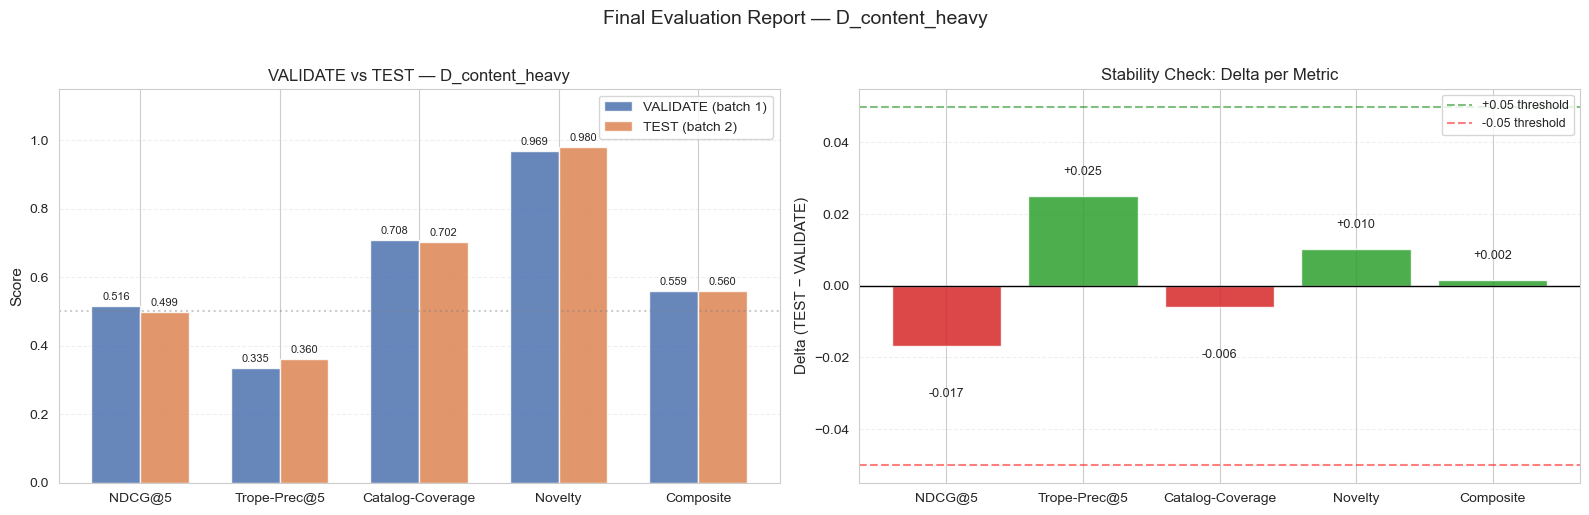

In [118]:
_metrics_cmp = ['NDCG@5','Trope-Prec@5','Catalog-Coverage','Novelty','Composite']
_x  = np.arange(len(_metrics_cmp))
_w  = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Bar chart ─────────────────────────────────────────────────────────────
ax = axes[0]
b1 = ax.bar(_x - _w/2, _report.loc[0, _metrics_cmp], _w,
            label='VALIDATE (batch 1)', color='#4C72B0', alpha=0.85)
b2 = ax.bar(_x + _w/2, _report.loc[1, _metrics_cmp], _w,
            label='TEST (batch 2)',     color='#DD8452', alpha=0.85)
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(_x)
ax.set_xticklabels(_metrics_cmp, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(f'VALIDATE vs TEST — {_best_cfg_name}', fontsize=12)
ax.legend(fontsize=10)
ax.axhline(0.5, color='grey', linestyle=':', alpha=0.4)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# ── Delta bar ─────────────────────────────────────────────────────────────
ax2 = axes[1]
deltas = [_report.loc[1,m] - _report.loc[0,m] for m in _metrics_cmp]
colors_d = ['#2ca02c' if d >= 0 else '#d62728' for d in deltas]
ax2.bar(_x, deltas, color=colors_d, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=1)
ax2.axhline( 0.05, color='green', linestyle='--', alpha=0.5, label='+0.05 threshold')
ax2.axhline(-0.05, color='red',   linestyle='--', alpha=0.5, label='-0.05 threshold')
for i, (d, m) in enumerate(zip(deltas, _metrics_cmp)):
    ax2.text(i, d + (0.005 if d >= 0 else -0.015),
             f'{d:+.3f}', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(_x)
ax2.set_xticklabels(_metrics_cmp, fontsize=10)
ax2.set_ylabel('Delta (TEST − VALIDATE)', fontsize=11)
ax2.set_title('Stability Check: Delta per Metric', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle(f'Final Evaluation Report — {_best_cfg_name}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Insight: Trade-off Analysis

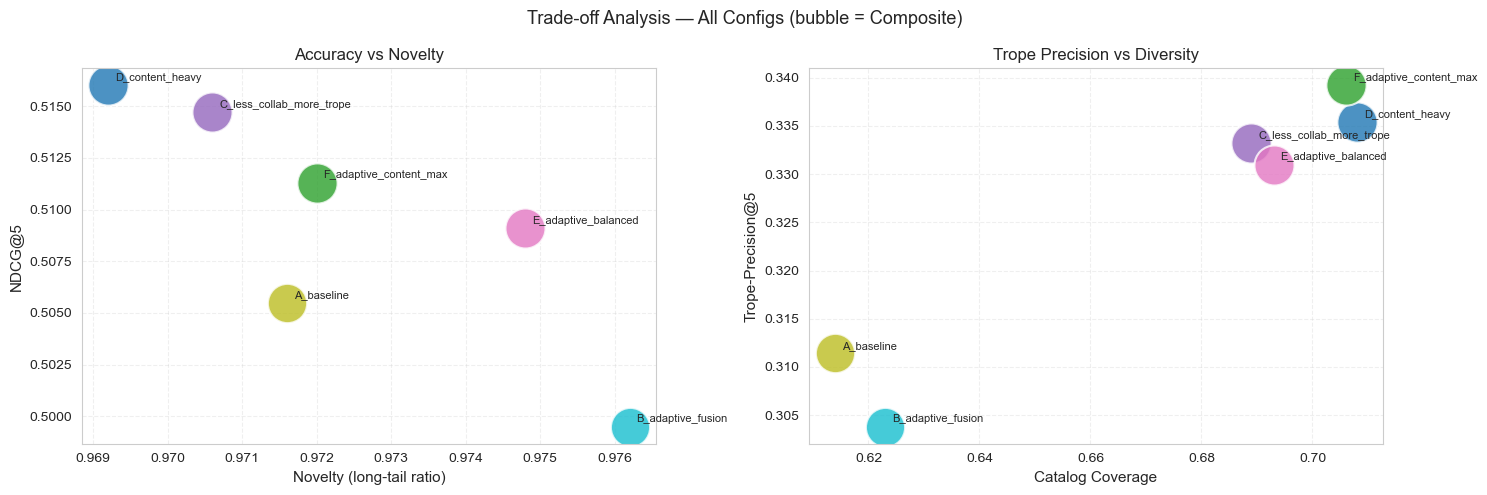


Key Insights:
   Best NDCG@5            : D_content_heavy
   Best Novelty           : B_adaptive_fusion
   Best Catalog-Coverage  : D_content_heavy
   Best Composite (winner): D_content_heavy

   ccuracy-Novelty trade-off tồn tại — best accuracy ≠ best novelty


In [119]:
# ── Trade-off: Accuracy vs Novelty vs Coverage (all 6 configs) ────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
colors_ = plt.cm.tab10(np.linspace(0, 1, len(gs_results)))

# Accuracy vs Novelty
for (_, row), c in zip(gs_results.iterrows(), colors_):
    ax1.scatter(row['Novelty'], row['NDCG@5'],
                s=row['Composite']*1500, color=c, alpha=0.8,
                edgecolors='white', linewidth=1.5)
    ax1.annotate(row['config'], (row['Novelty'], row['NDCG@5']),
                 textcoords='offset points', xytext=(5,3), fontsize=8)
ax1.set_xlabel('Novelty (long-tail ratio)', fontsize=11)
ax1.set_ylabel('NDCG@5', fontsize=11)
ax1.set_title('Accuracy vs Novelty', fontsize=12)
ax1.grid(linestyle='--', alpha=0.3)

# Accuracy vs Coverage
for (_, row), c in zip(gs_results.iterrows(), colors_):
    ax2.scatter(row['Catalog-Coverage'], row['Trope-Prec@5'],
                s=row['Composite']*1500, color=c, alpha=0.8,
                edgecolors='white', linewidth=1.5)
    ax2.annotate(row['config'], (row['Catalog-Coverage'], row['Trope-Prec@5']),
                 textcoords='offset points', xytext=(5,3), fontsize=8)
ax2.set_xlabel('Catalog Coverage', fontsize=11)
ax2.set_ylabel('Trope-Precision@5', fontsize=11)
ax2.set_title('Trope Precision vs Diversity', fontsize=12)
ax2.grid(linestyle='--', alpha=0.3)

plt.suptitle('Trade-off Analysis — All Configs (bubble = Composite)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Summary insights ──────────────────────────────────────────────────────
print("\nKey Insights:")
_best_ndcg = gs_results.loc[gs_results['NDCG@5'].idxmax(), 'config']
_best_nov  = gs_results.loc[gs_results['Novelty'].idxmax(), 'config']
_best_cov  = gs_results.loc[gs_results['Catalog-Coverage'].idxmax(), 'config']
print(f"   Best NDCG@5            : {_best_ndcg}")
print(f"   Best Novelty           : {_best_nov}")
print(f"   Best Catalog-Coverage  : {_best_cov}")
print(f"   Best Composite (winner): {gs_results.iloc[0]['config']}")

if _best_ndcg != _best_nov:
    print("\n   ccuracy-Novelty trade-off tồn tại — best accuracy ≠ best novelty")
if gs_results[gs_results['Novelty'] > 0.5].empty:
    print("   Tất cả configs bias popular — cân nhắc thêm diversity mechanism")